<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Selection_Rules_Visualized_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

In [8]:
!uv pip install -q "qutip>=5.0" numpy scipy matplotlib

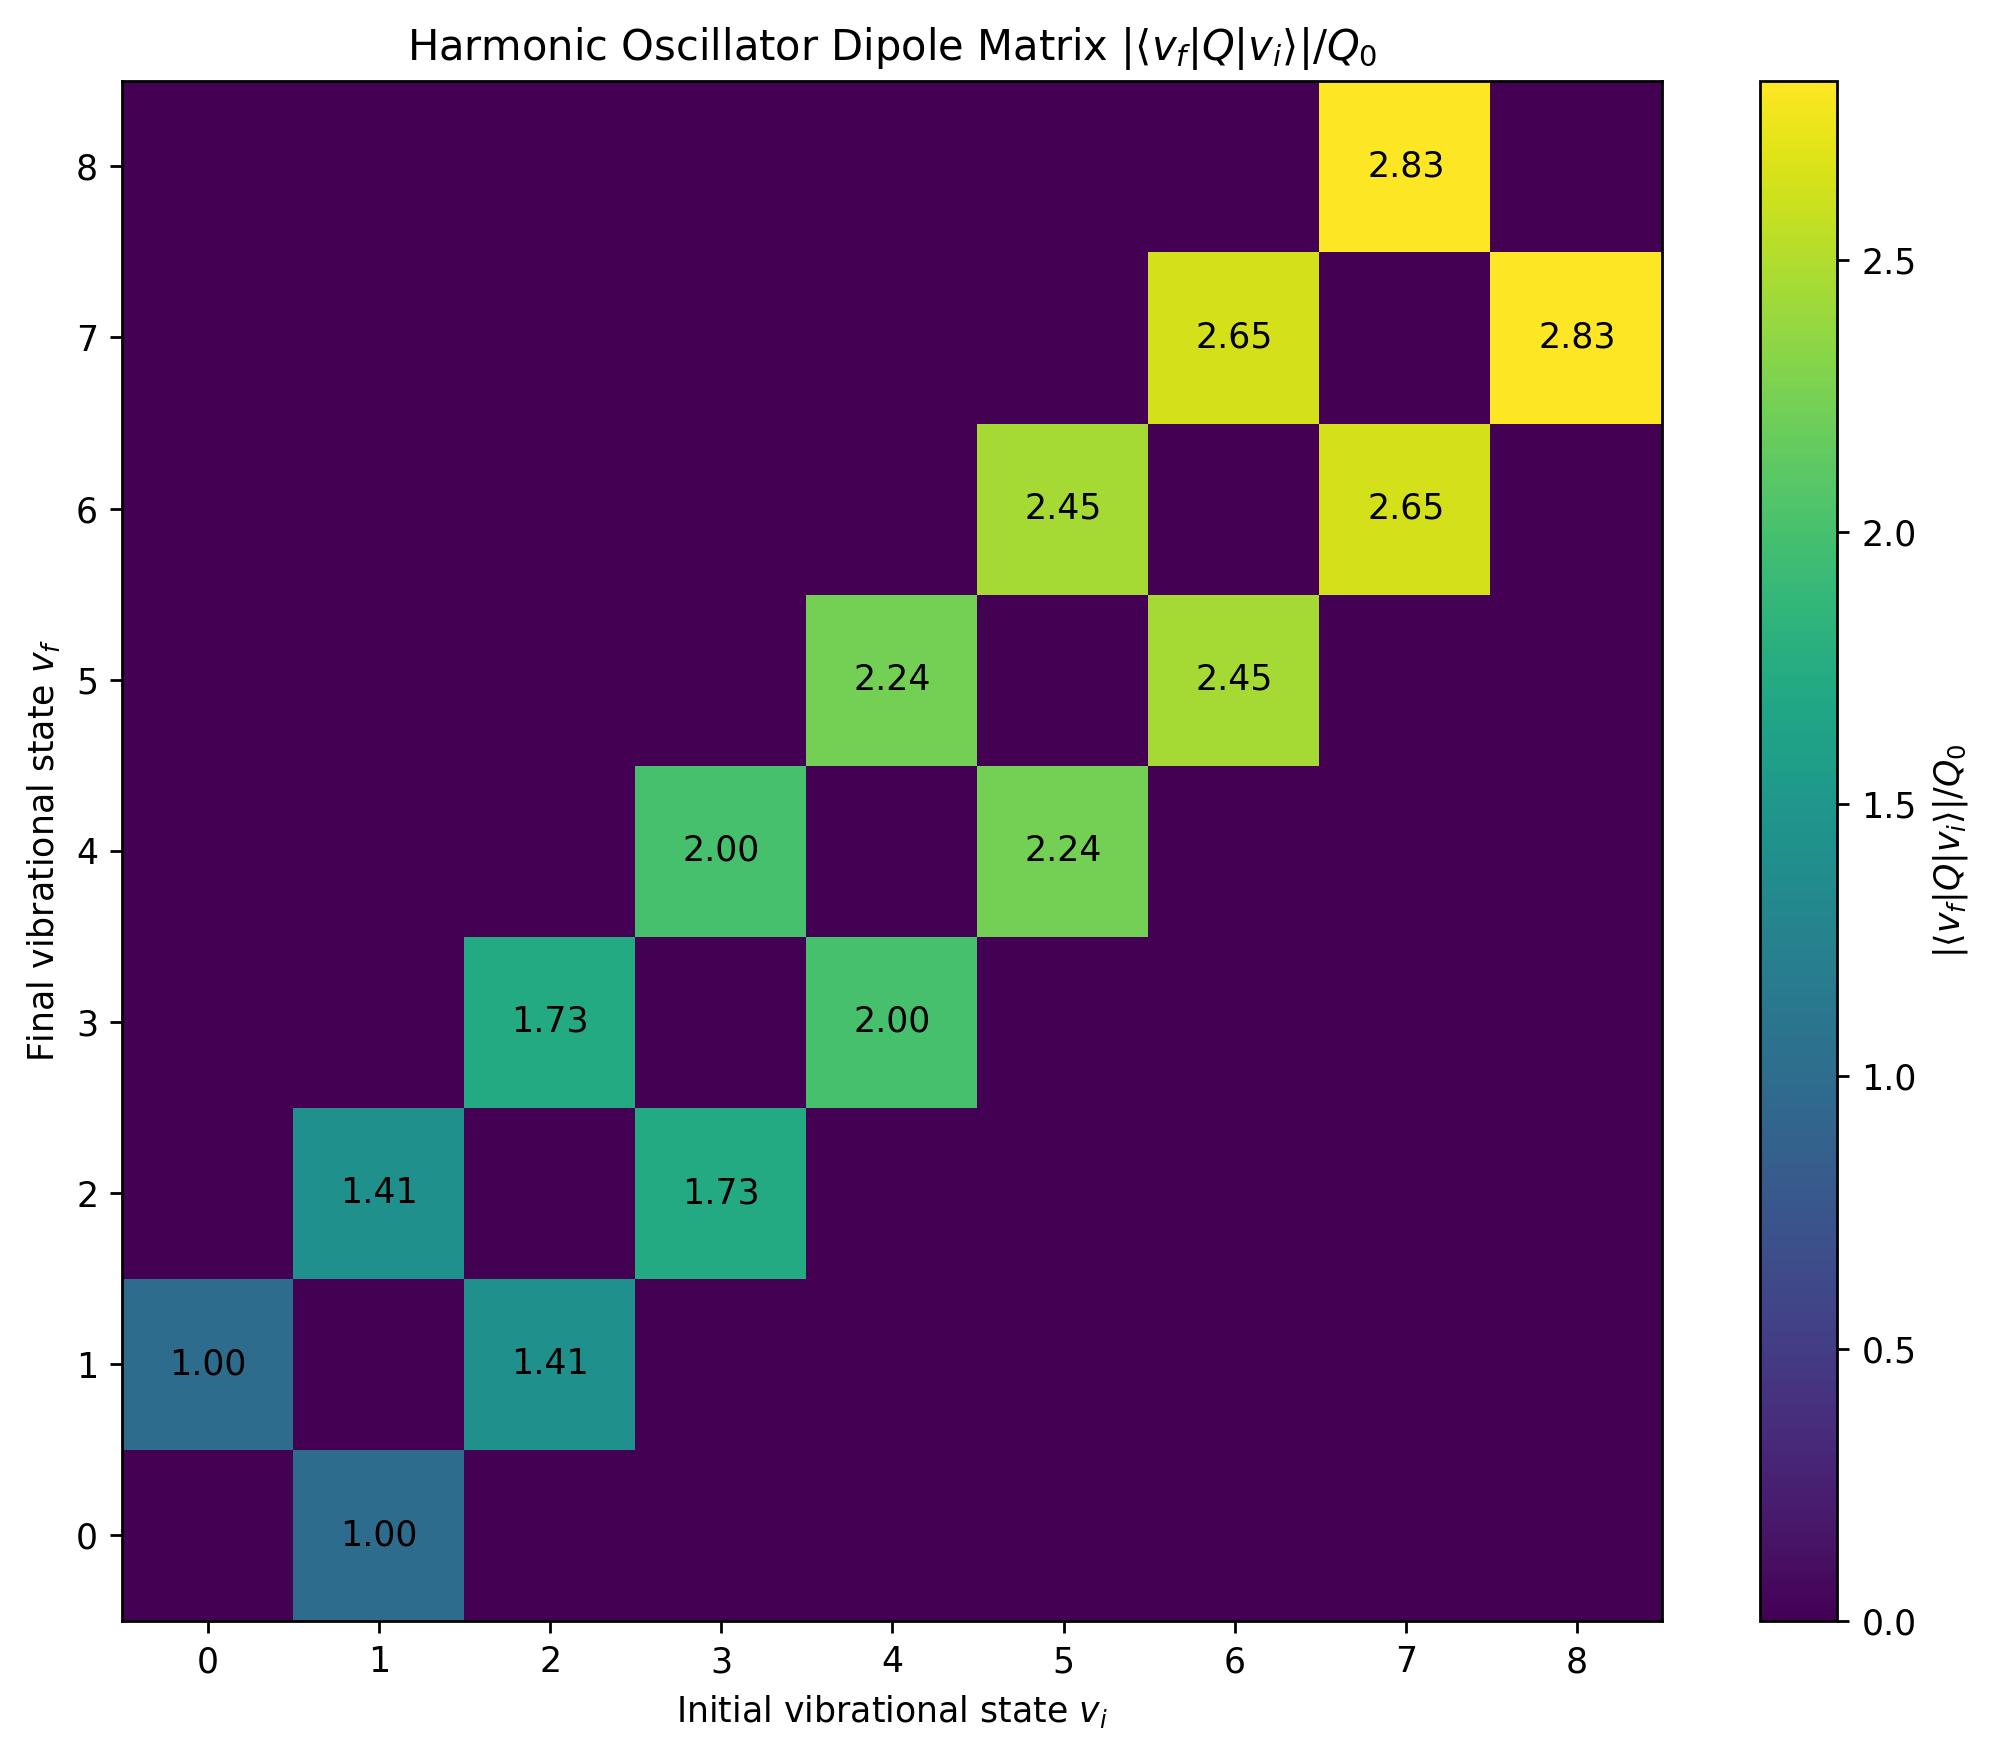

In [9]:
"""Visualize harmonic oscillator electric dipole selection rules."""

import matplotlib.pyplot as plt
import numpy as np


# ------------------------------------------------------------
# CONTROL KNOBS
# ------------------------------------------------------------
NUM_VIBRATIONAL_LEVELS = 9
PLOT_DPI = 250
FIGURE_SIZE = (8.5, 7.0)
ANNOTATE_MATRIX = True

plt.rcParams["figure.dpi"] = PLOT_DPI


def build_position_matrix(num_levels: int) -> np.ndarray:
    """Build the harmonic oscillator position matrix in units of Q_0.

    Args:
        num_levels: Number of vibrational basis states.

    Returns:
        Matrix whose rows are final states and columns are initial states.
    """
    matrix = np.zeros((num_levels, num_levels), dtype=float)

    for v_initial in range(num_levels):
        if v_initial + 1 < num_levels:
            matrix[v_initial + 1, v_initial] = np.sqrt(v_initial + 1)

        if v_initial >= 1:
            matrix[v_initial - 1, v_initial] = np.sqrt(v_initial)

    return matrix


def plot_selection_rule_heatmap(matrix: np.ndarray) -> None:
    """Plot the harmonic oscillator transition matrix as a heat map."""
    figure, axis = plt.subplots(figsize=FIGURE_SIZE)

    image = axis.imshow(
        np.abs(matrix),
        origin="lower",
        aspect="equal",
    )

    indices = np.arange(matrix.shape[0])
    axis.set_xticks(indices)
    axis.set_yticks(indices)
    axis.set_xlabel(r"Initial vibrational state $v_i$")
    axis.set_ylabel(r"Final vibrational state $v_f$")
    axis.set_title(
        r"Harmonic Oscillator Dipole Matrix "
        r"$|\langle v_f|Q|v_i\rangle|/Q_0$"
    )

    if ANNOTATE_MATRIX:
        for row in range(matrix.shape[0]):
            for column in range(matrix.shape[1]):
                value = abs(matrix[row, column])
                if value > 0.0:
                    axis.text(
                        column,
                        row,
                        f"{value:.2f}",
                        ha="center",
                        va="center",
                    )

    figure.colorbar(
        image,
        ax=axis,
        label=r"$|\langle v_f|Q|v_i\rangle|/Q_0$",
    )

    figure.tight_layout()
    plt.show()


position_matrix = build_position_matrix(NUM_VIBRATIONAL_LEVELS)
plot_selection_rule_heatmap(position_matrix)

Hydrogen 1s -> 2p0 electric dipole transition
Analytic <2p0|z|1s>/a0 = 0.7449355390
Numeric  <2p0|z|1s>/a0 = 0.7449355390
Transition coordinate = 3.942029e-11 m
Transition dipole = 6.315827e-30 C m
Transition dipole = 1.893438 D
Energy gap = 10.204270 eV
Angular frequency = 1.550302e+16 rad/s
Coulomb model wavelength = 121.5023 nm
Spontaneous E1 rate = 6.268315e+08 1/s
Lifetime = 1.595325 ns


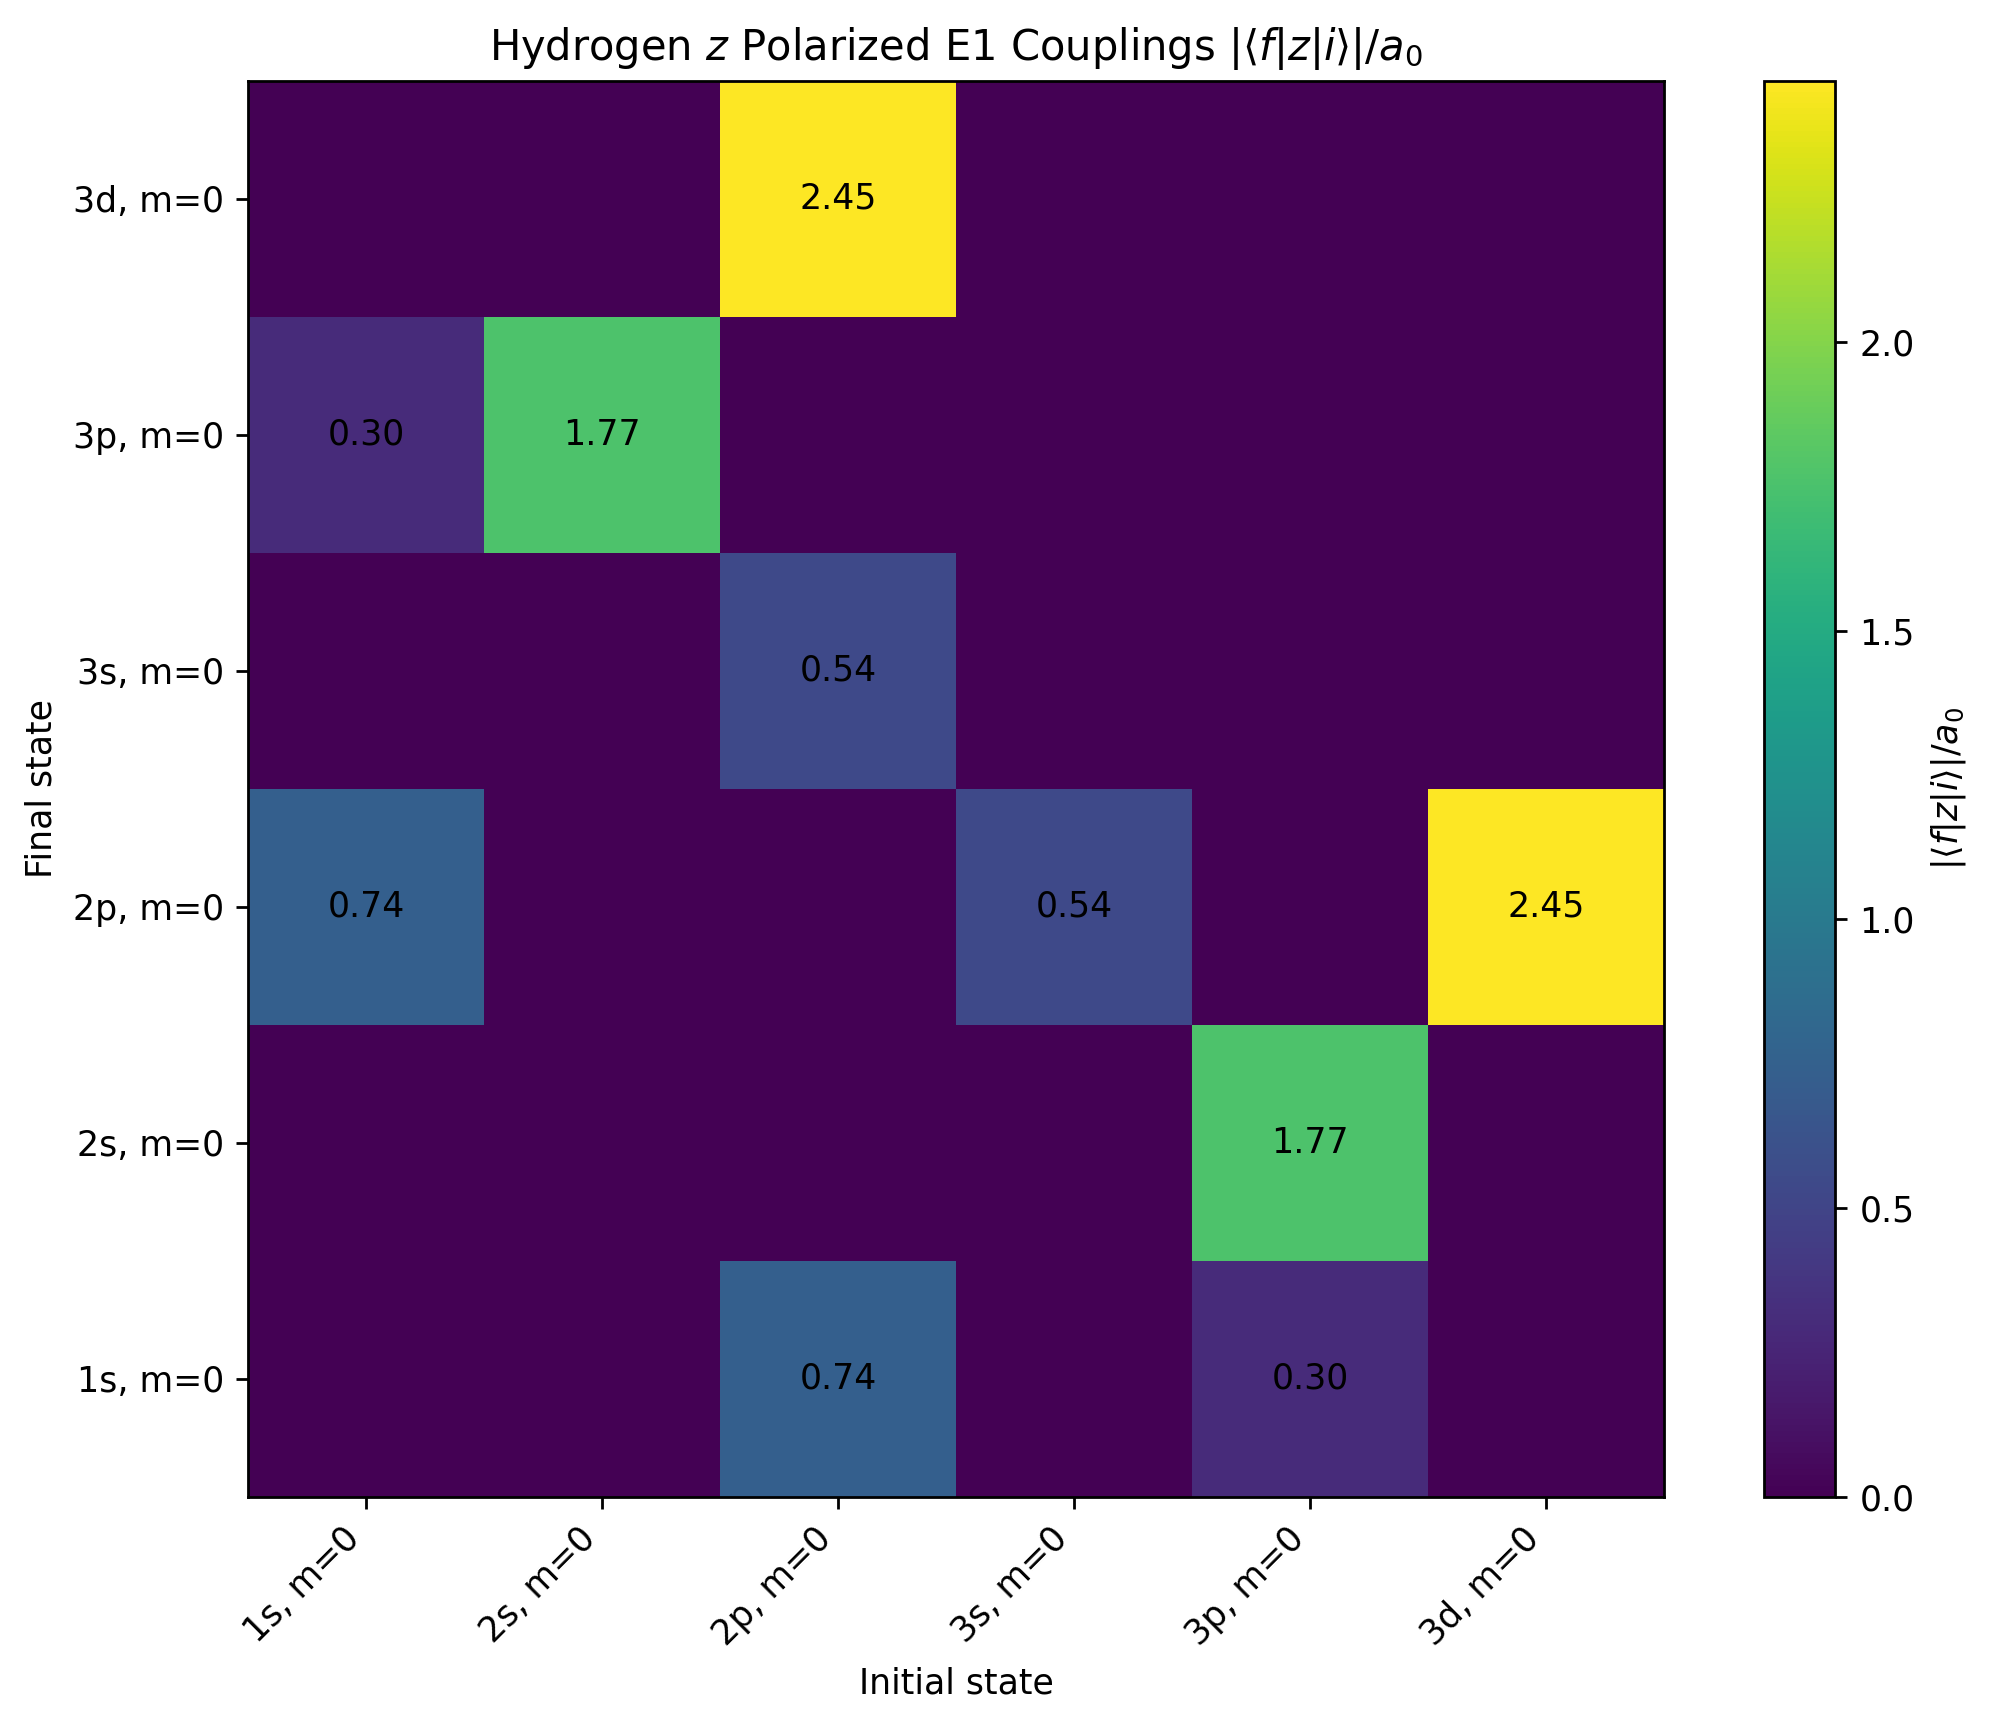

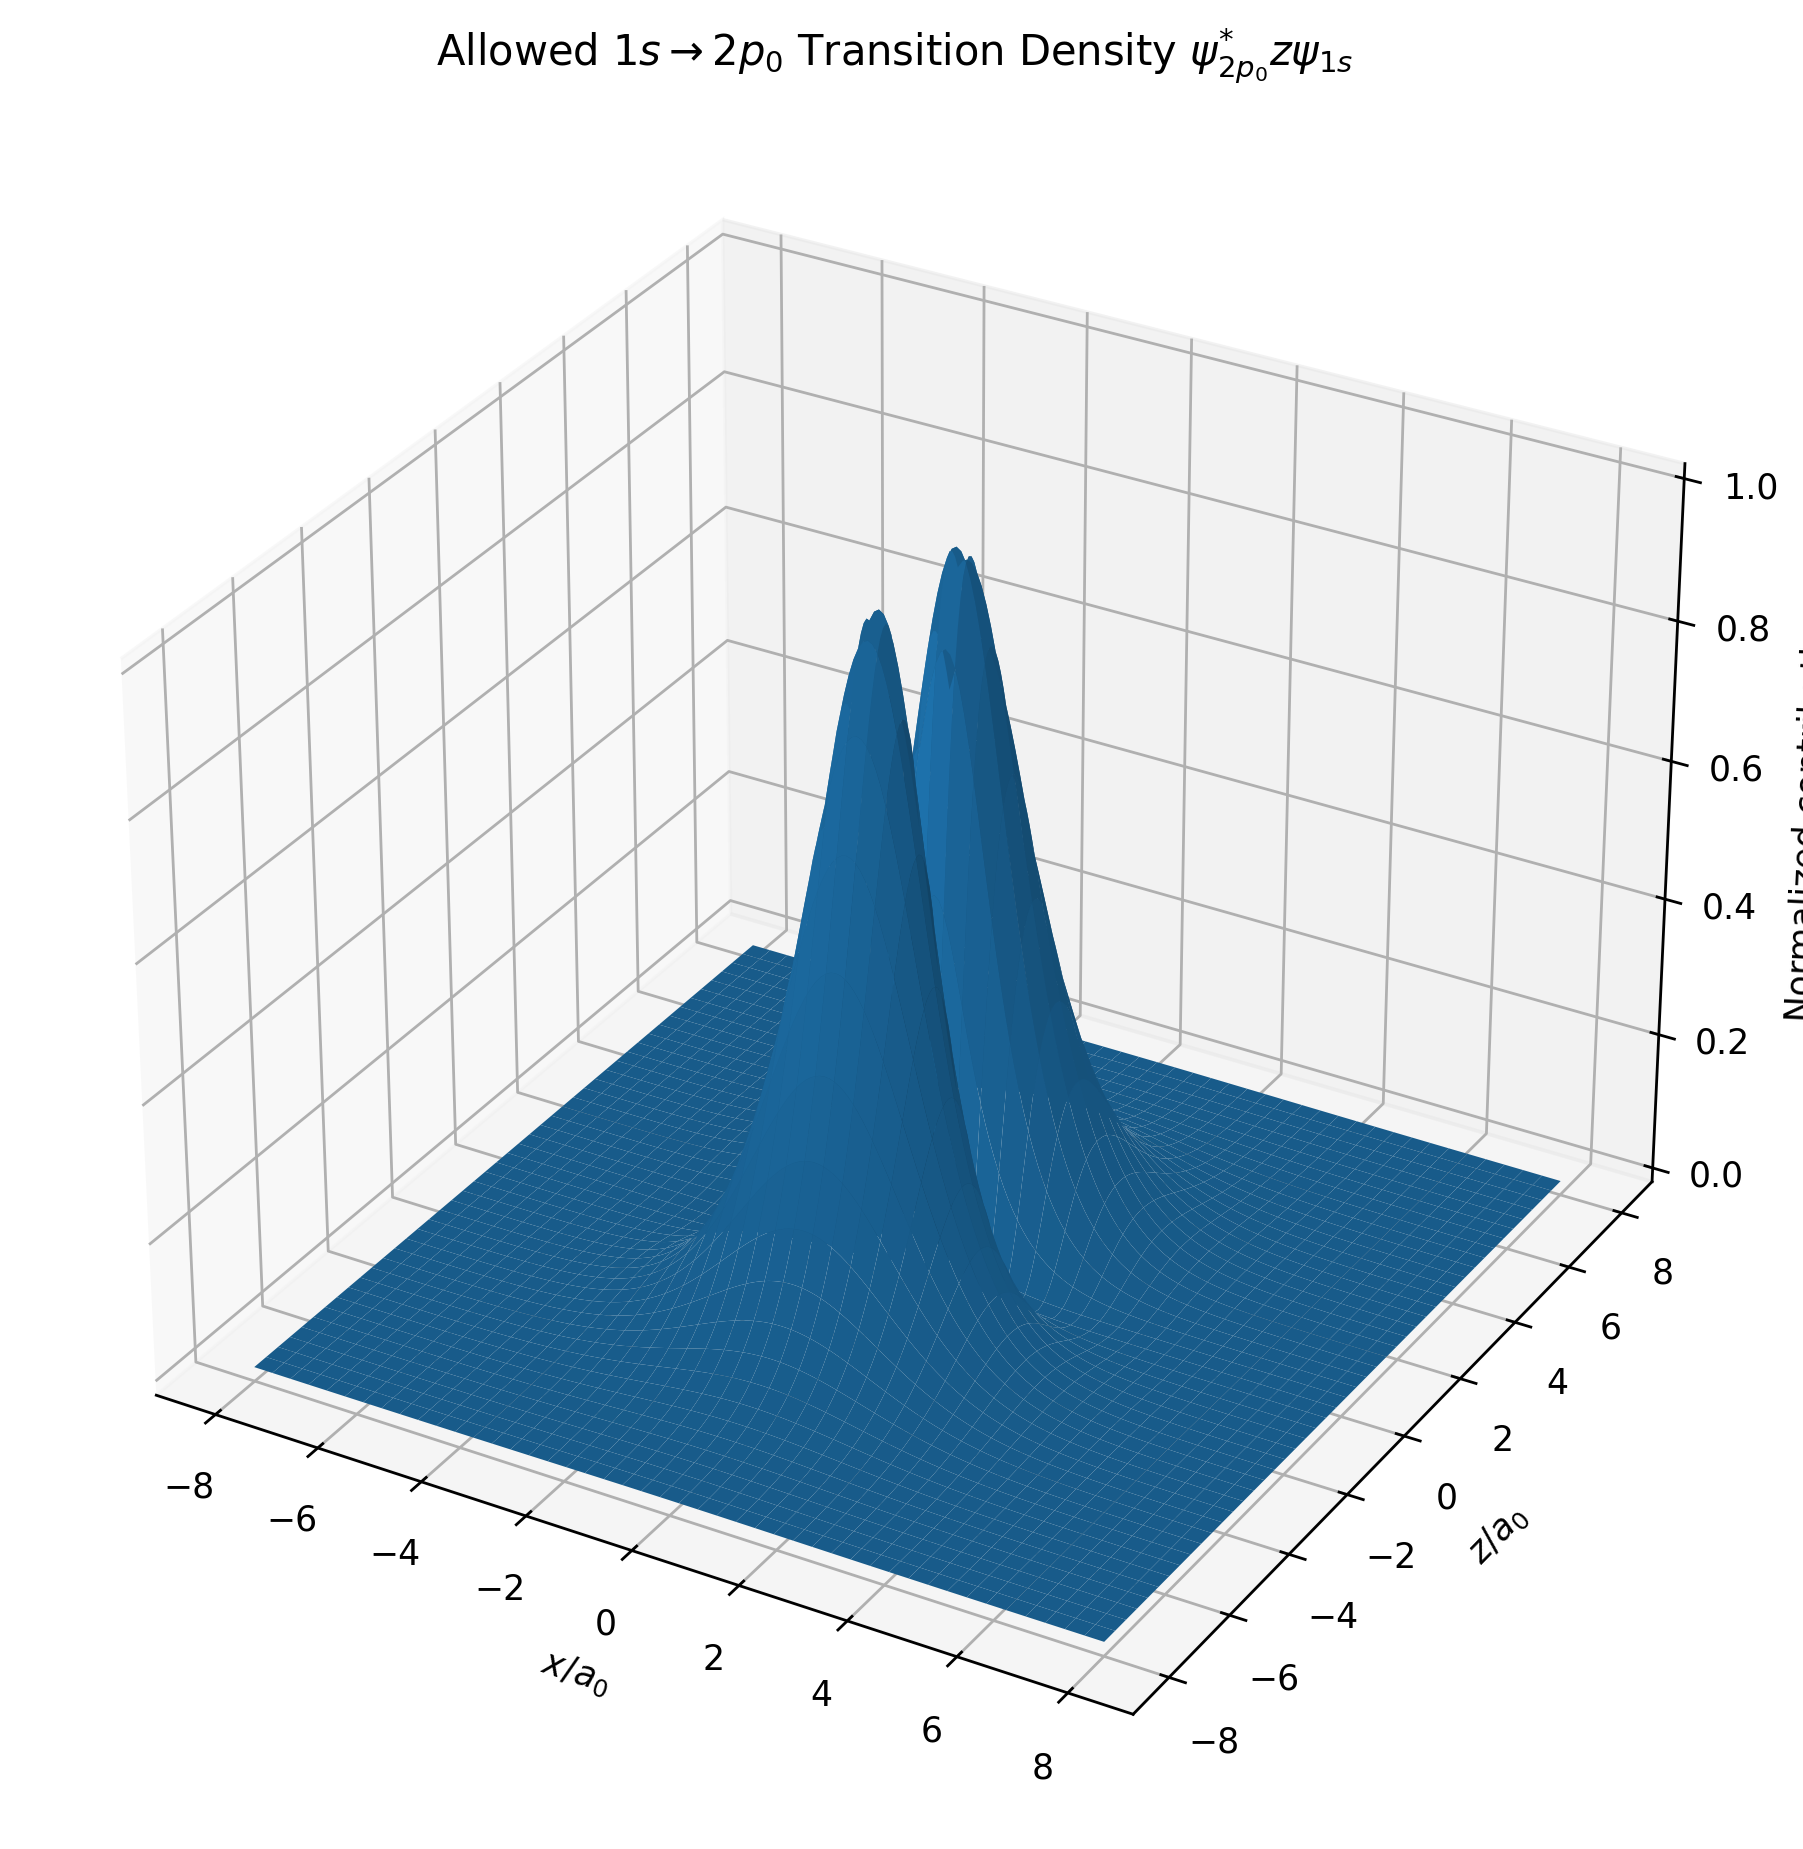

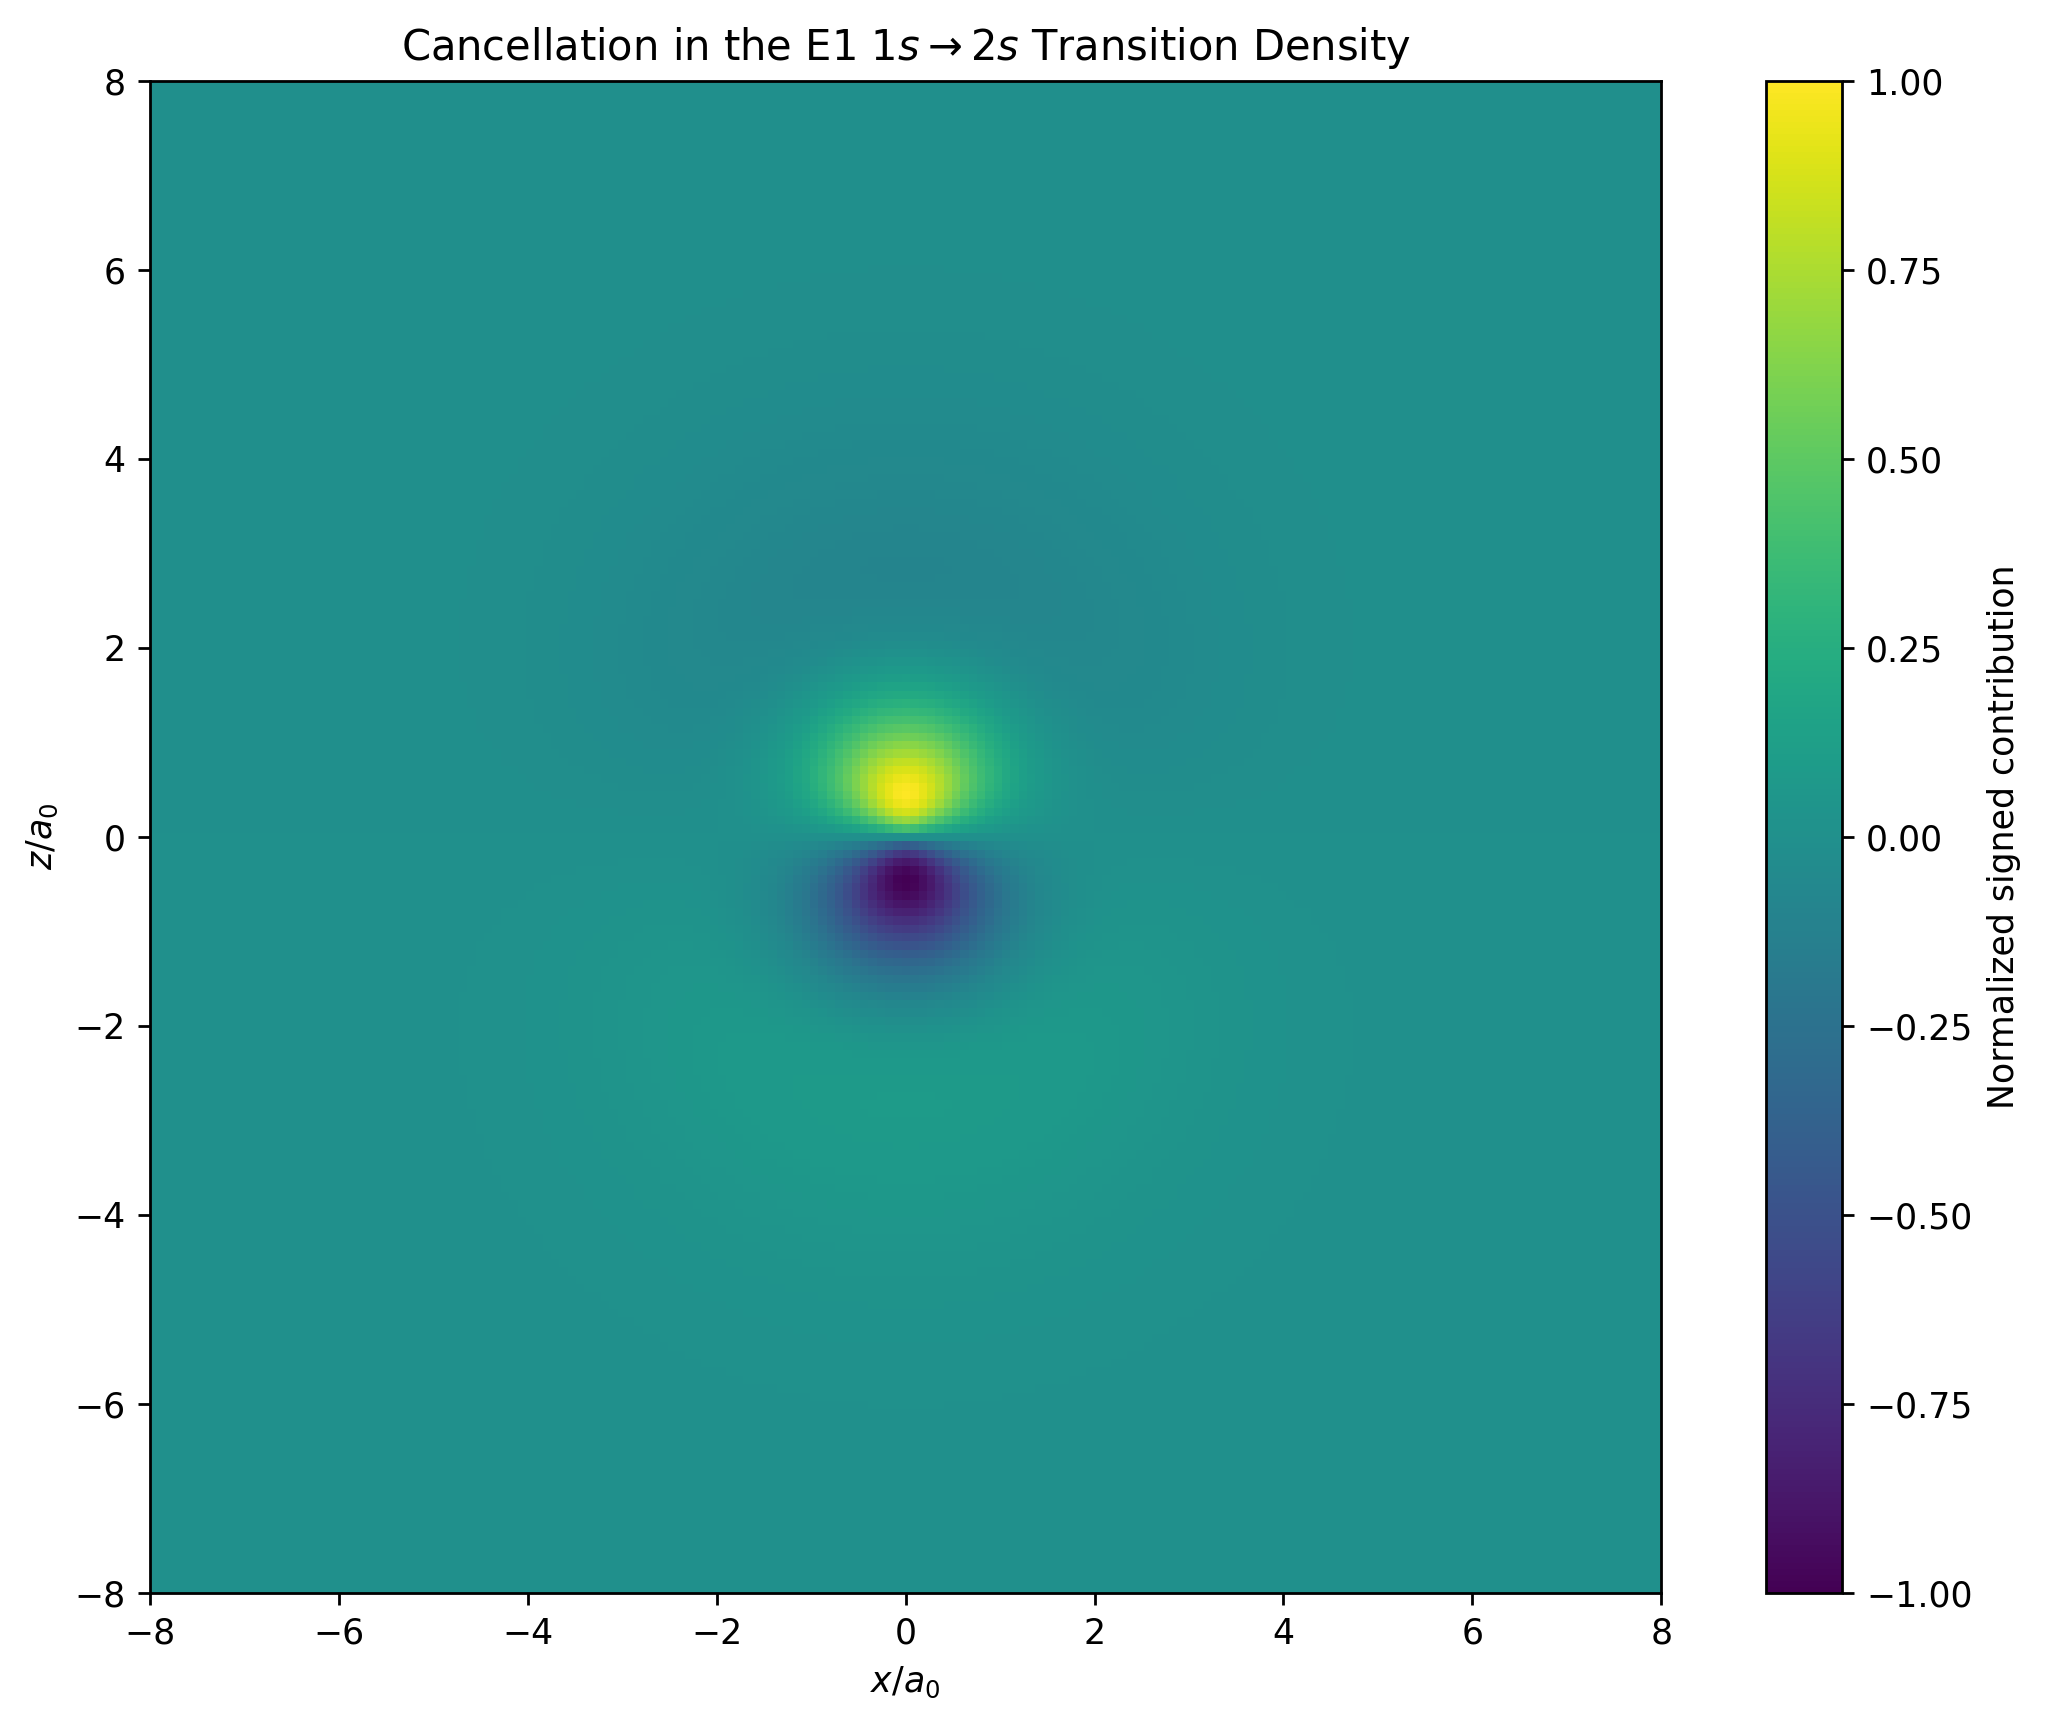

In [10]:
"""Compute and visualize hydrogen electric dipole selection rules."""

from functools import lru_cache
import math

import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import quad
from scipy.special import eval_genlaguerre


# ------------------------------------------------------------
# CONTROL KNOBS
# ------------------------------------------------------------
PLOT_DPI = 250
MAX_PRINCIPAL_QUANTUM_NUMBER = 3
RADIAL_INTEGRATION_LIMIT_A0 = 100.0
SURFACE_EXTENT_A0 = 8.0
SURFACE_POINTS = 181
M_QUANTUM_NUMBER = 0
ANNOTATE_MATRIX = True
FIGURE_SIZE = (9.0, 7.0)

# Physical constants.
BOHR_RADIUS_M = 5.291_772_109_03e-11
ELEMENTARY_CHARGE_C = 1.602_176_634e-19
HBAR_J_S = 1.054_571_817e-34
EPSILON_0_F_M = 8.854_187_812_8e-12
SPEED_OF_LIGHT_M_S = 299_792_458.0
ELECTRON_VOLT_J = 1.602_176_634e-19
RYDBERG_ENERGY_EV = 13.605_693_122_994
DEBYE_C_M = 3.335_64e-30

ORBITAL_SYMBOLS = ("s", "p", "d", "f", "g", "h")

plt.rcParams["figure.dpi"] = PLOT_DPI


def hydrogen_radial(
    n: int,
    l_value: int,
    radius_a0: float | np.ndarray,
) -> float | np.ndarray:
    """Evaluate a normalized hydrogen radial function.

    The radial coordinate is expressed in units of the Bohr radius.
    The returned radial function is therefore expressed in normalized
    atomic units.

    Args:
        n: Principal quantum number.
        l_value: Orbital angular momentum quantum number.
        radius_a0: Radius divided by the Bohr radius.

    Returns:
        Normalized radial wavefunction in atomic units.
    """
    rho = 2.0 * np.asarray(radius_a0) / n

    prefactor = math.sqrt(
        (2.0 / n) ** 3
        * math.factorial(n - l_value - 1)
        / (
            2.0
            * n
            * math.factorial(n + l_value)
        )
    )

    radial = (
        prefactor
        * np.exp(-rho / 2.0)
        * rho**l_value
        * eval_genlaguerre(
            n - l_value - 1,
            2 * l_value + 1,
            rho,
        )
    )

    return radial


def z_angular_factor(
    l_initial: int,
    m_initial: int,
    l_final: int,
    m_final: int,
) -> float:
    """Return the angular factor for a z polarized E1 transition.

    Args:
        l_initial: Initial orbital angular momentum.
        m_initial: Initial magnetic quantum number.
        l_final: Final orbital angular momentum.
        m_final: Final magnetic quantum number.

    Returns:
        Angular matrix element of cos(theta).
    """
    if m_final != m_initial:
        return 0.0

    if l_final == l_initial + 1:
        numerator = (l_initial + 1) ** 2 - m_initial**2
        denominator = (
            (2 * l_initial + 1)
            * (2 * l_initial + 3)
        )
        return math.sqrt(numerator / denominator)

    if l_initial >= 1 and l_final == l_initial - 1:
        numerator = l_initial**2 - m_initial**2
        denominator = (
            (2 * l_initial - 1)
            * (2 * l_initial + 1)
        )
        return math.sqrt(numerator / denominator)

    return 0.0


@lru_cache(maxsize=None)
def radial_position_integral(
    n_initial: int,
    l_initial: int,
    n_final: int,
    l_final: int,
) -> float:
    """Evaluate the radial factor in a position matrix element.

    Args:
        n_initial: Initial principal quantum number.
        l_initial: Initial orbital angular momentum.
        n_final: Final principal quantum number.
        l_final: Final orbital angular momentum.

    Returns:
        Radial integral in units of the Bohr radius.
    """

    def integrand(radius_a0: float) -> float:
        """Evaluate the radial quadrature integrand."""
        initial = float(
            hydrogen_radial(
                n_initial,
                l_initial,
                radius_a0,
            )
        )
        final = float(
            hydrogen_radial(
                n_final,
                l_final,
                radius_a0,
            )
        )

        return final * initial * radius_a0**3

    value, _ = quad(
        integrand,
        0.0,
        RADIAL_INTEGRATION_LIMIT_A0,
        epsabs=1.0e-11,
        epsrel=1.0e-11,
        limit=300,
    )

    return value


def hydrogen_z_matrix_element(
    n_initial: int,
    l_initial: int,
    m_initial: int,
    n_final: int,
    l_final: int,
    m_final: int,
) -> float:
    """Calculate a hydrogen z matrix element in units of a_0.

    Args:
        n_initial: Initial principal quantum number.
        l_initial: Initial orbital angular momentum.
        m_initial: Initial magnetic quantum number.
        n_final: Final principal quantum number.
        l_final: Final orbital angular momentum.
        m_final: Final magnetic quantum number.

    Returns:
        Position matrix element divided by the Bohr radius.
    """
    angular = z_angular_factor(
        l_initial,
        m_initial,
        l_final,
        m_final,
    )

    if angular == 0.0:
        return 0.0

    radial = radial_position_integral(
        n_initial,
        l_initial,
        n_final,
        l_final,
    )

    return angular * radial


def build_state_list(
    max_n: int,
    m_value: int,
) -> list[tuple[int, int, int]]:
    """Build hydrogen states compatible with a selected m value."""
    states = []

    for n in range(1, max_n + 1):
        for l_value in range(abs(m_value), n):
            states.append((n, l_value, m_value))

    return states


def state_label(state: tuple[int, int, int]) -> str:
    """Create a compact spectroscopic state label."""
    n, l_value, m_value = state
    orbital = ORBITAL_SYMBOLS[l_value]
    return f"{n}{orbital}, m={m_value}"


def build_transition_matrix(
    states: list[tuple[int, int, int]],
) -> np.ndarray:
    """Build absolute z matrix elements for distinct n manifolds."""
    size = len(states)
    matrix = np.zeros((size, size), dtype=float)

    for initial_index, initial_state in enumerate(states):
        for final_index, final_state in enumerate(states):
            n_initial = initial_state[0]
            n_final = final_state[0]

            if n_initial == n_final:
                continue

            matrix[final_index, initial_index] = abs(
                hydrogen_z_matrix_element(
                    *initial_state,
                    *final_state,
                )
            )

    return matrix


def print_lyman_calculation() -> None:
    """Print the analytic and numerical 1s to 2p0 results."""
    analytic_position_a0 = (
        2.0**8
        / (
            3.0**5
            * math.sqrt(2.0)
        )
    )

    numerical_position_a0 = abs(
        hydrogen_z_matrix_element(
            1,
            0,
            0,
            2,
            1,
            0,
        )
    )

    position_m = (
        analytic_position_a0
        * BOHR_RADIUS_M
    )
    dipole_c_m = (
        ELEMENTARY_CHARGE_C
        * position_m
    )
    dipole_debye = (
        dipole_c_m
        / DEBYE_C_M
    )

    energy_gap_ev = (
        0.75
        * RYDBERG_ENERGY_EV
    )
    energy_gap_j = (
        energy_gap_ev
        * ELECTRON_VOLT_J
    )
    omega_rad_s = (
        energy_gap_j
        / HBAR_J_S
    )
    wavelength_m = (
        2.0
        * math.pi
        * SPEED_OF_LIGHT_M_S
        / omega_rad_s
    )

    spontaneous_rate_s = (
        omega_rad_s**3
        * dipole_c_m**2
        / (
            3.0
            * math.pi
            * EPSILON_0_F_M
            * HBAR_J_S
            * SPEED_OF_LIGHT_M_S**3
        )
    )
    lifetime_s = 1.0 / spontaneous_rate_s

    print("Hydrogen 1s -> 2p0 electric dipole transition")
    print(
        "Analytic <2p0|z|1s>/a0 = "
        f"{analytic_position_a0:.10f}"
    )
    print(
        "Numeric  <2p0|z|1s>/a0 = "
        f"{numerical_position_a0:.10f}"
    )
    print(
        "Transition coordinate = "
        f"{position_m:.6e} m"
    )
    print(
        "Transition dipole = "
        f"{dipole_c_m:.6e} C m"
    )
    print(
        "Transition dipole = "
        f"{dipole_debye:.6f} D"
    )
    print(
        "Energy gap = "
        f"{energy_gap_ev:.6f} eV"
    )
    print(
        "Angular frequency = "
        f"{omega_rad_s:.6e} rad/s"
    )
    print(
        "Coulomb model wavelength = "
        f"{wavelength_m * 1.0e9:.4f} nm"
    )
    print(
        "Spontaneous E1 rate = "
        f"{spontaneous_rate_s:.6e} 1/s"
    )
    print(
        "Lifetime = "
        f"{lifetime_s * 1.0e9:.6f} ns"
    )


def plot_transition_matrix() -> None:
    """Plot low lying hydrogen z dipole matrix elements."""
    states = build_state_list(
        MAX_PRINCIPAL_QUANTUM_NUMBER,
        M_QUANTUM_NUMBER,
    )
    matrix = build_transition_matrix(states)
    labels = [state_label(state) for state in states]

    figure, axis = plt.subplots(figsize=FIGURE_SIZE)

    image = axis.imshow(
        matrix,
        origin="lower",
        aspect="equal",
    )

    indices = np.arange(len(states))
    axis.set_xticks(
        indices,
        labels,
        rotation=45,
        ha="right",
    )
    axis.set_yticks(
        indices,
        labels,
    )

    axis.set_xlabel("Initial state")
    axis.set_ylabel("Final state")
    axis.set_title(
        r"Hydrogen $z$ Polarized E1 Couplings "
        r"$|\langle f|z|i\rangle|/a_0$"
    )

    if ANNOTATE_MATRIX:
        for row in range(matrix.shape[0]):
            for column in range(matrix.shape[1]):
                value = matrix[row, column]
                if value > 1.0e-4:
                    axis.text(
                        column,
                        row,
                        f"{value:.2f}",
                        ha="center",
                        va="center",
                    )

    figure.colorbar(
        image,
        ax=axis,
        label=r"$|\langle f|z|i\rangle|/a_0$",
    )

    figure.tight_layout()
    plt.show()


def orbital_fields(
    x_grid: np.ndarray,
    z_grid: np.ndarray,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Evaluate 1s, 2s, and 2p0 hydrogen orbitals in atomic units."""
    radius = np.sqrt(
        x_grid**2
        + z_grid**2
    )

    psi_1s = (
        np.exp(-radius)
        / math.sqrt(math.pi)
    )

    psi_2s = (
        (2.0 - radius)
        * np.exp(-radius / 2.0)
        / (
            4.0
            * math.sqrt(2.0 * math.pi)
        )
    )

    psi_2p0 = (
        z_grid
        * np.exp(-radius / 2.0)
        / (
            4.0
            * math.sqrt(2.0 * math.pi)
        )
    )

    return psi_1s, psi_2s, psi_2p0


def plot_allowed_transition_surface() -> None:
    """Plot the 1s to 2p0 z transition density as a 3D surface."""
    coordinate = np.linspace(
        -SURFACE_EXTENT_A0,
        SURFACE_EXTENT_A0,
        SURFACE_POINTS,
    )
    x_grid, z_grid = np.meshgrid(
        coordinate,
        coordinate,
    )

    psi_1s, _, psi_2p0 = orbital_fields(
        x_grid,
        z_grid,
    )

    transition_density = (
        psi_2p0
        * z_grid
        * psi_1s
    )

    scale = np.max(
        np.abs(transition_density)
    )
    normalized = transition_density / scale

    figure = plt.figure(
        figsize=(9.5, 7.5)
    )
    axis = figure.add_subplot(
        111,
        projection="3d",
    )

    axis.plot_surface(
        x_grid,
        z_grid,
        normalized,
        linewidth=0.0,
        antialiased=True,
    )

    axis.set_xlabel(r"$x/a_0$")
    axis.set_ylabel(r"$z/a_0$")
    axis.set_zlabel("Normalized contribution")
    axis.set_title(
        r"Allowed $1s\rightarrow2p_0$ "
        r"Transition Density "
        r"$\psi_{2p_0}^{*}z\psi_{1s}$"
    )

    figure.tight_layout()
    plt.show()


def plot_forbidden_transition_heatmap() -> None:
    """Plot cancellation in the 1s to 2s z transition density."""
    coordinate = np.linspace(
        -SURFACE_EXTENT_A0,
        SURFACE_EXTENT_A0,
        SURFACE_POINTS,
    )
    x_grid, z_grid = np.meshgrid(
        coordinate,
        coordinate,
    )

    psi_1s, psi_2s, _ = orbital_fields(
        x_grid,
        z_grid,
    )

    transition_density = (
        psi_2s
        * z_grid
        * psi_1s
    )

    scale = np.max(
        np.abs(transition_density)
    )
    normalized = transition_density / scale

    figure, axis = plt.subplots(
        figsize=FIGURE_SIZE
    )

    image = axis.imshow(
        normalized,
        origin="lower",
        extent=[
            -SURFACE_EXTENT_A0,
            SURFACE_EXTENT_A0,
            -SURFACE_EXTENT_A0,
            SURFACE_EXTENT_A0,
        ],
        aspect="equal",
        vmin=-1.0,
        vmax=1.0,
    )

    axis.set_xlabel(r"$x/a_0$")
    axis.set_ylabel(r"$z/a_0$")
    axis.set_title(
        r"Cancellation in the E1 "
        r"$1s\rightarrow2s$ Transition Density"
    )

    figure.colorbar(
        image,
        ax=axis,
        label="Normalized signed contribution",
    )

    figure.tight_layout()
    plt.show()


print_lyman_calculation()
plot_transition_matrix()
plot_allowed_transition_surface()
plot_forbidden_transition_heatmap()

Hydrogen 1s <-> 2p Fermi Golden Rule model
--------------------------------------------------------------
QuTiP version: 5.3.1
Transition energy: 10.204270 eV
Central wavelength: 121.5023 nm
Dipole position matrix element: 0.744935539 a0
Transition dipole magnitude: 6.315827e-30 C m
Population decay rate gamma_1: 6.250000e+08 s^-1
Coherence HWHM gamma_2 / 2pi: 49.7359 MHz

QuTiP steady-state comparison
----------------------------------------------------------------------------------------
 Field (V/m)   Detuning (MHz)        FGR (s^-1)      Bloch (s^-1)      QuTiP (s^-1)
       100.0           -100.0      1.138084e+04      1.138043e+04      1.138043e+04
       100.0              0.0      5.738893e+04      5.737839e+04      5.737839e+04
       100.0            100.0      1.138084e+04      1.138043e+04      1.138043e+04
      1000.0           -100.0      1.138084e+06      1.133955e+06      1.133955e+06
      1000.0              0.0      5.738893e+06      5.635402e+06      5.635402e+06
 

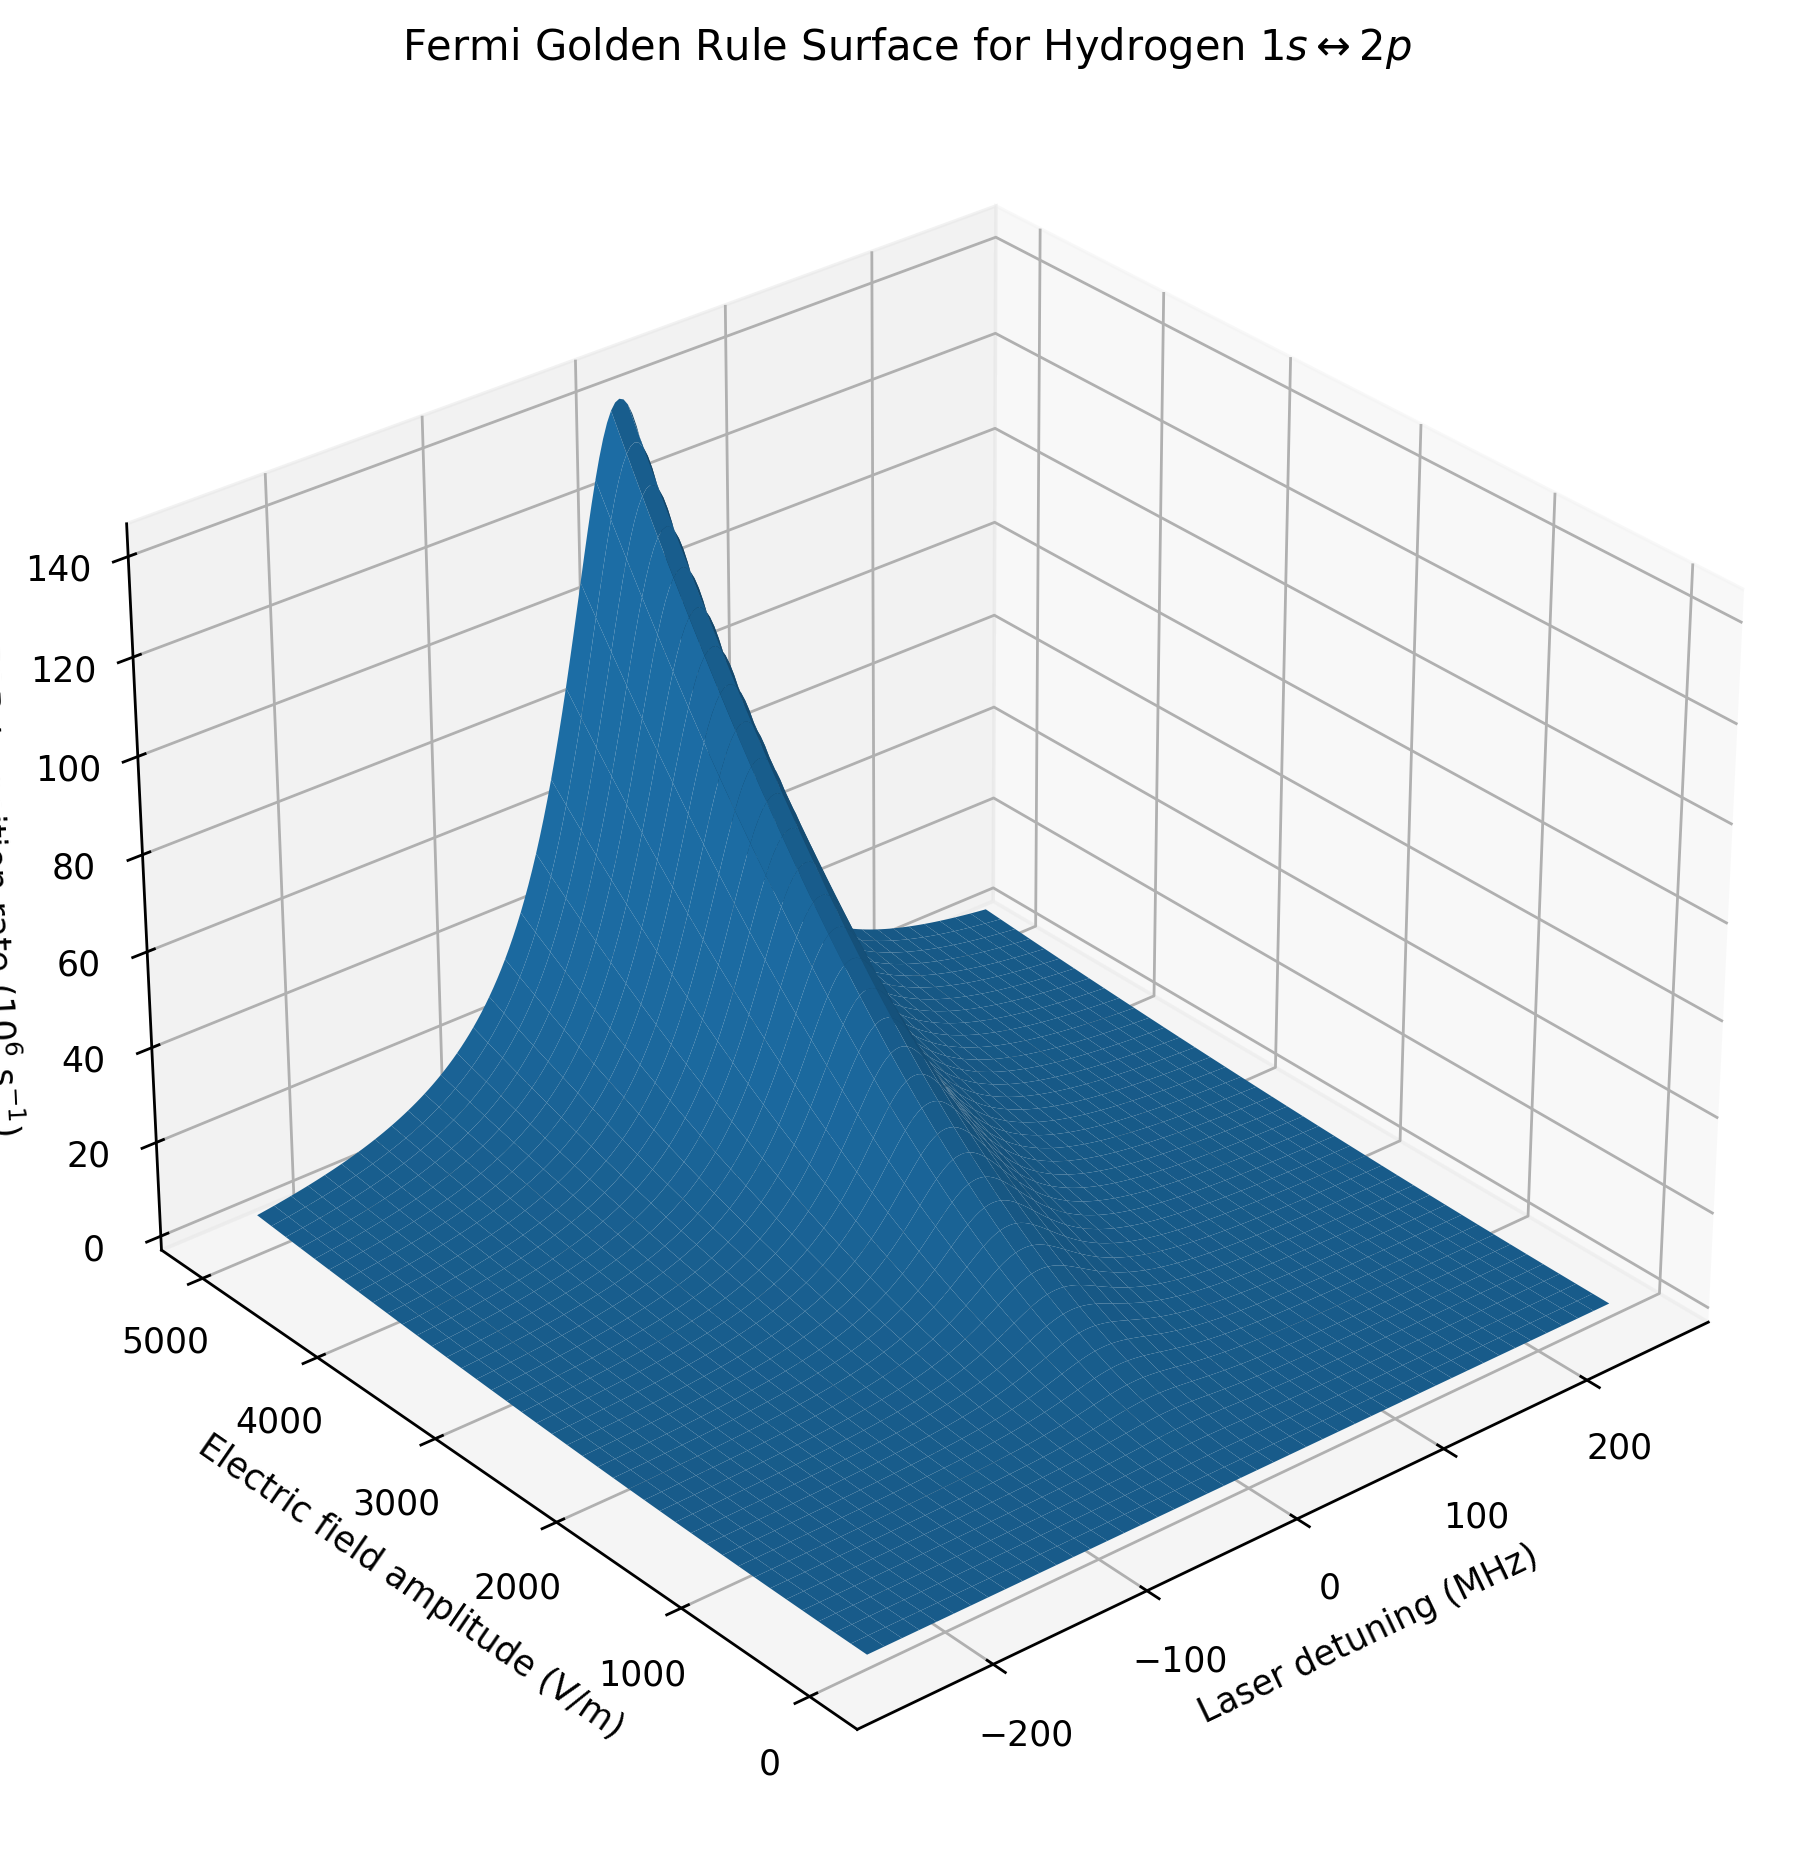

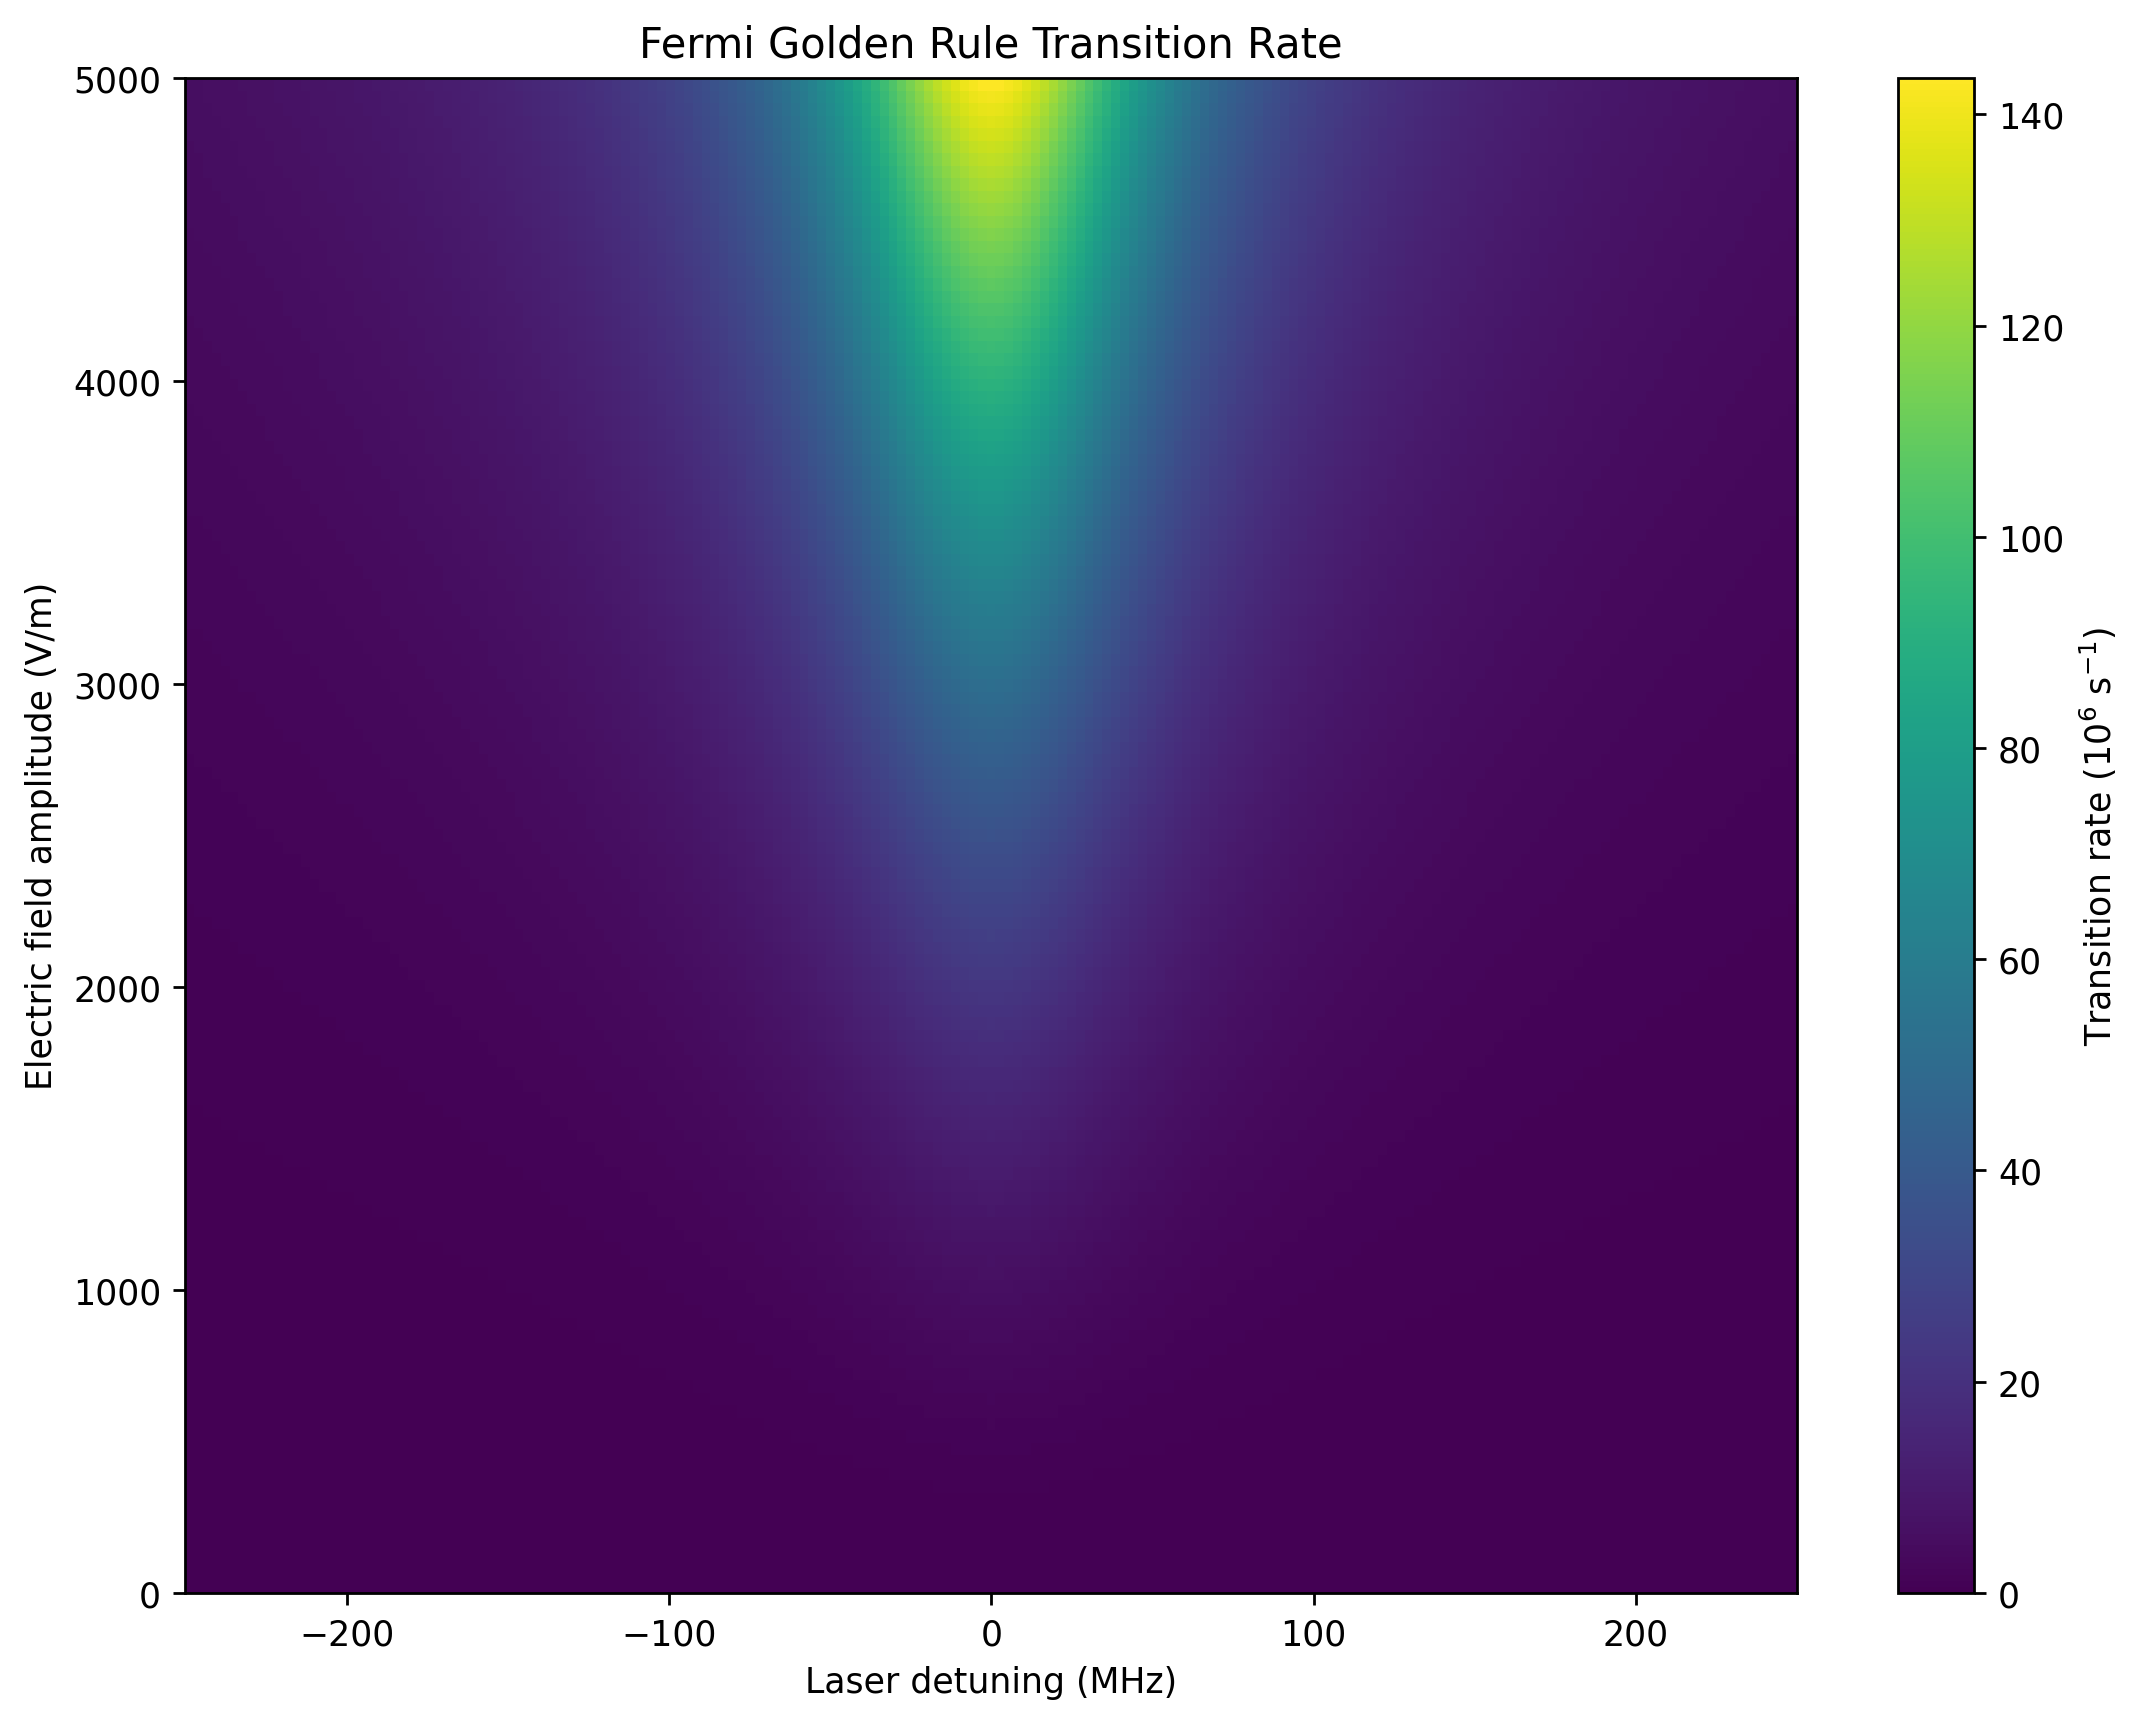

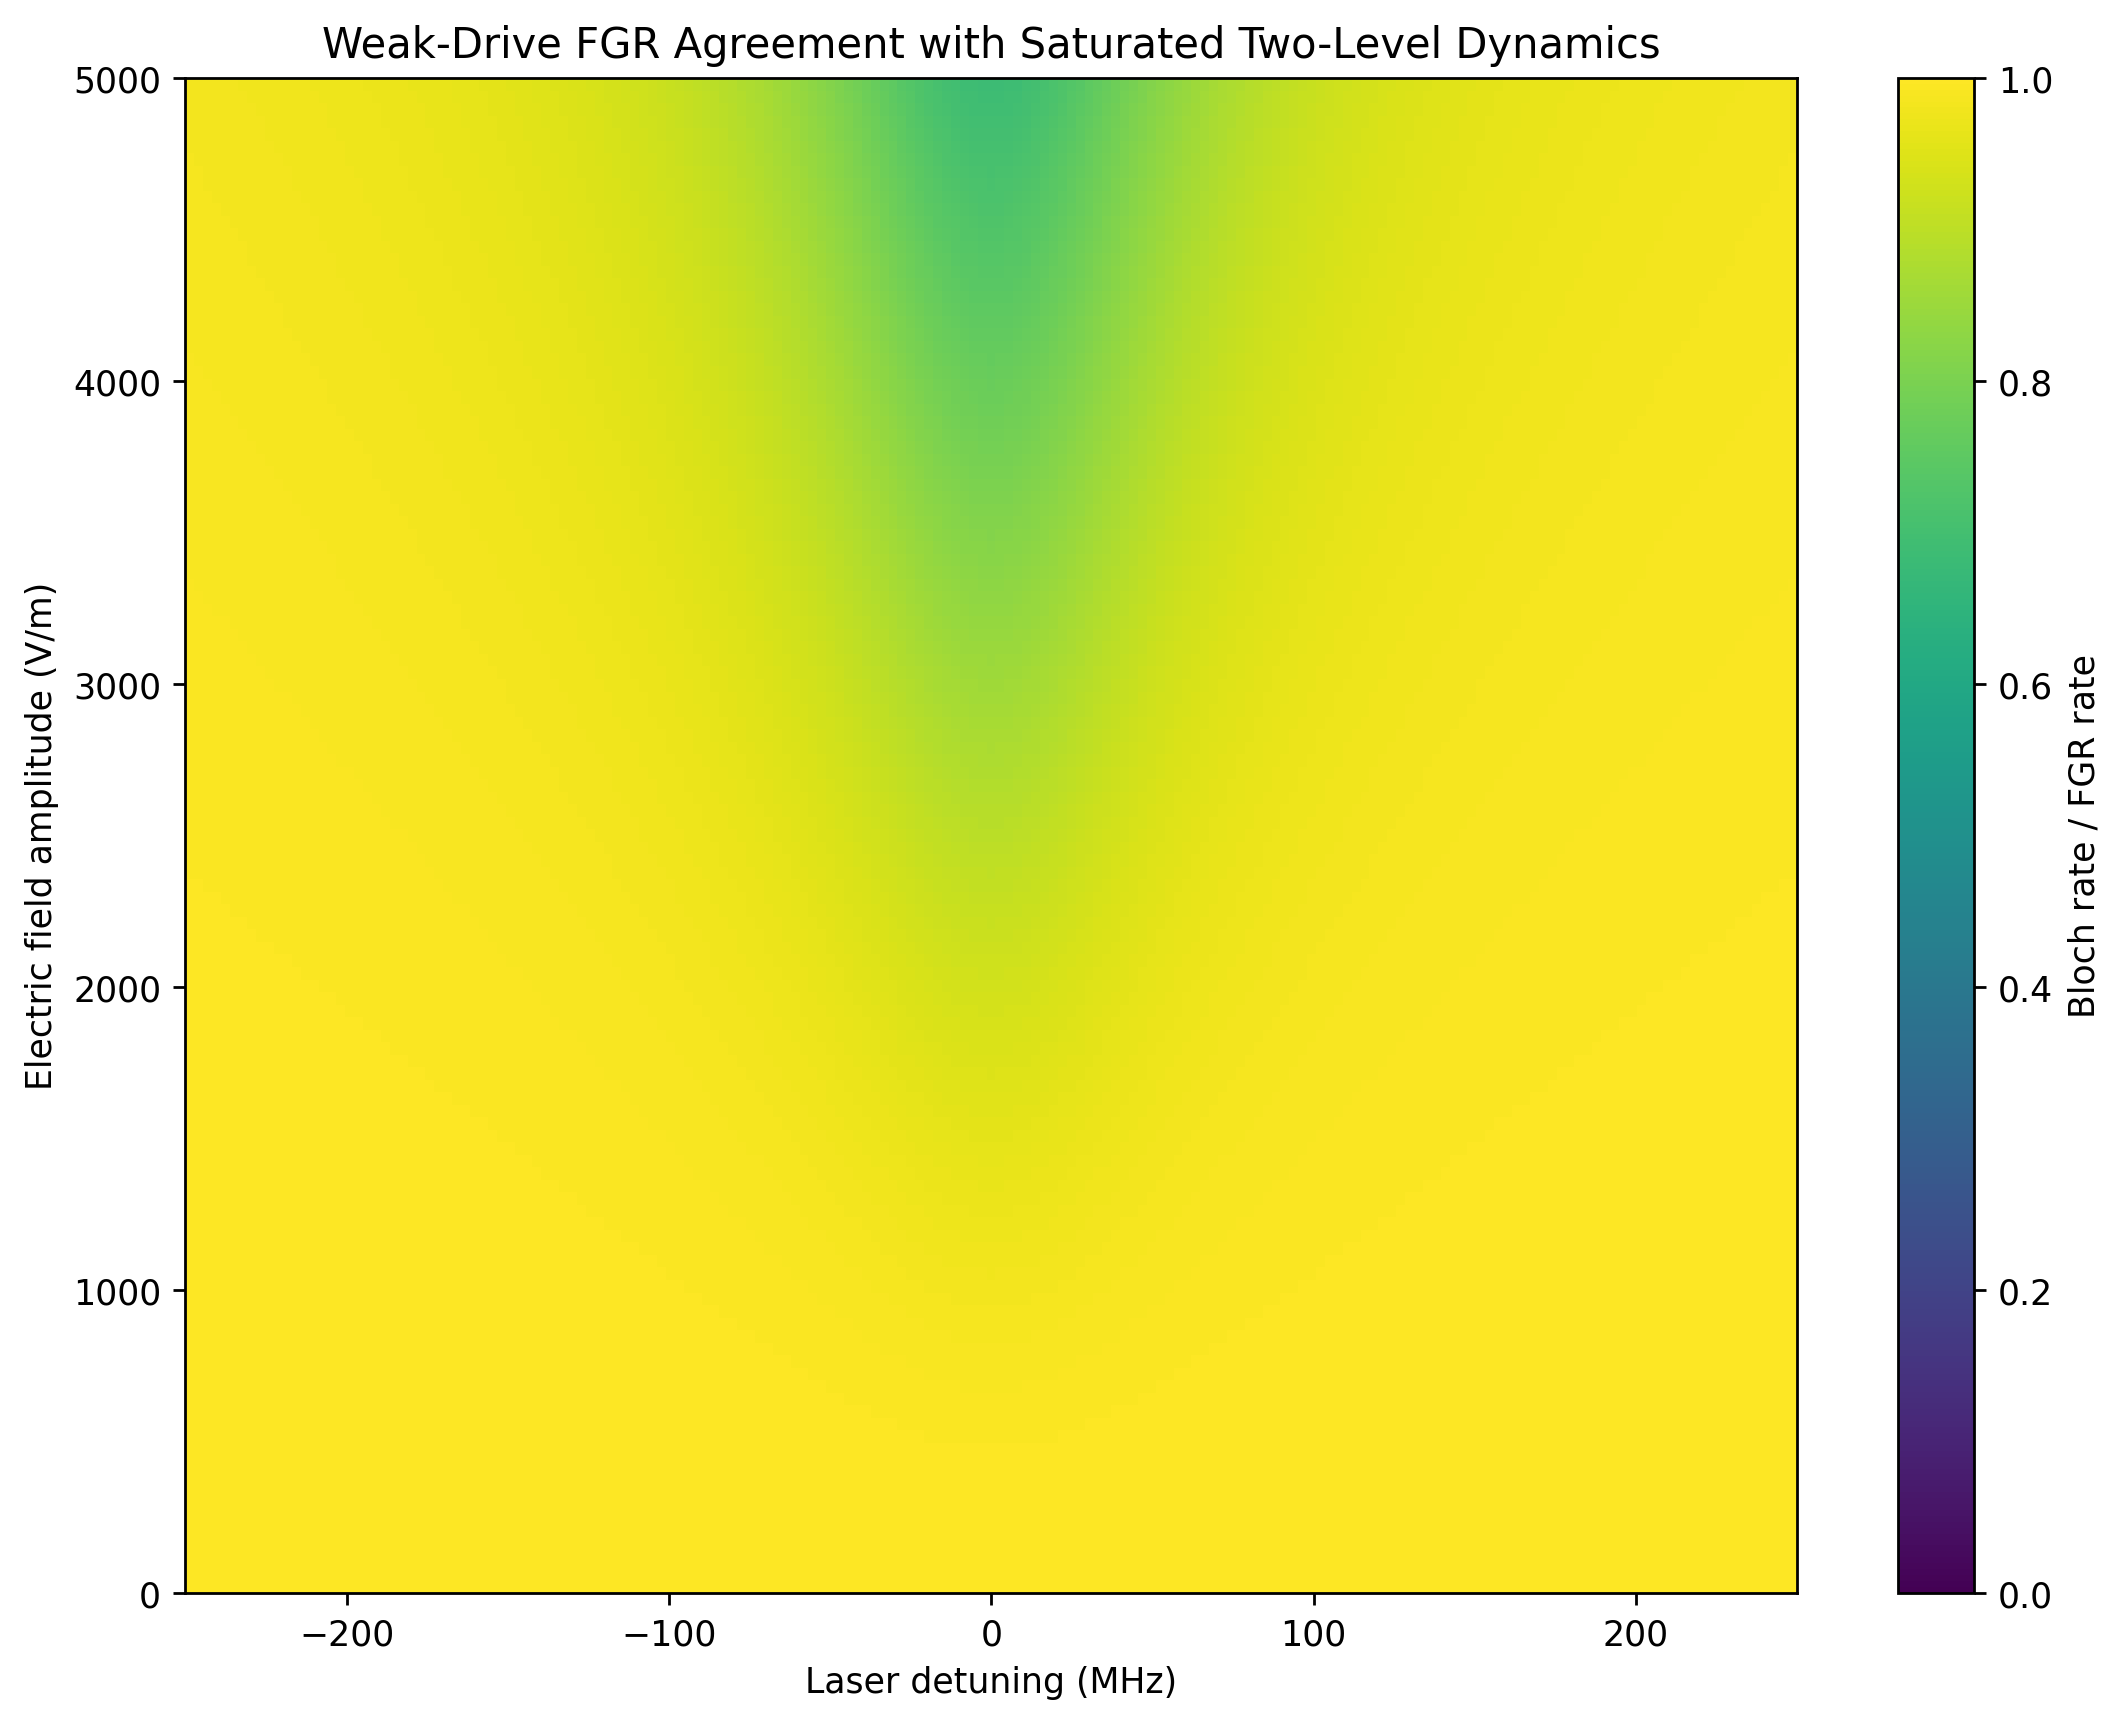

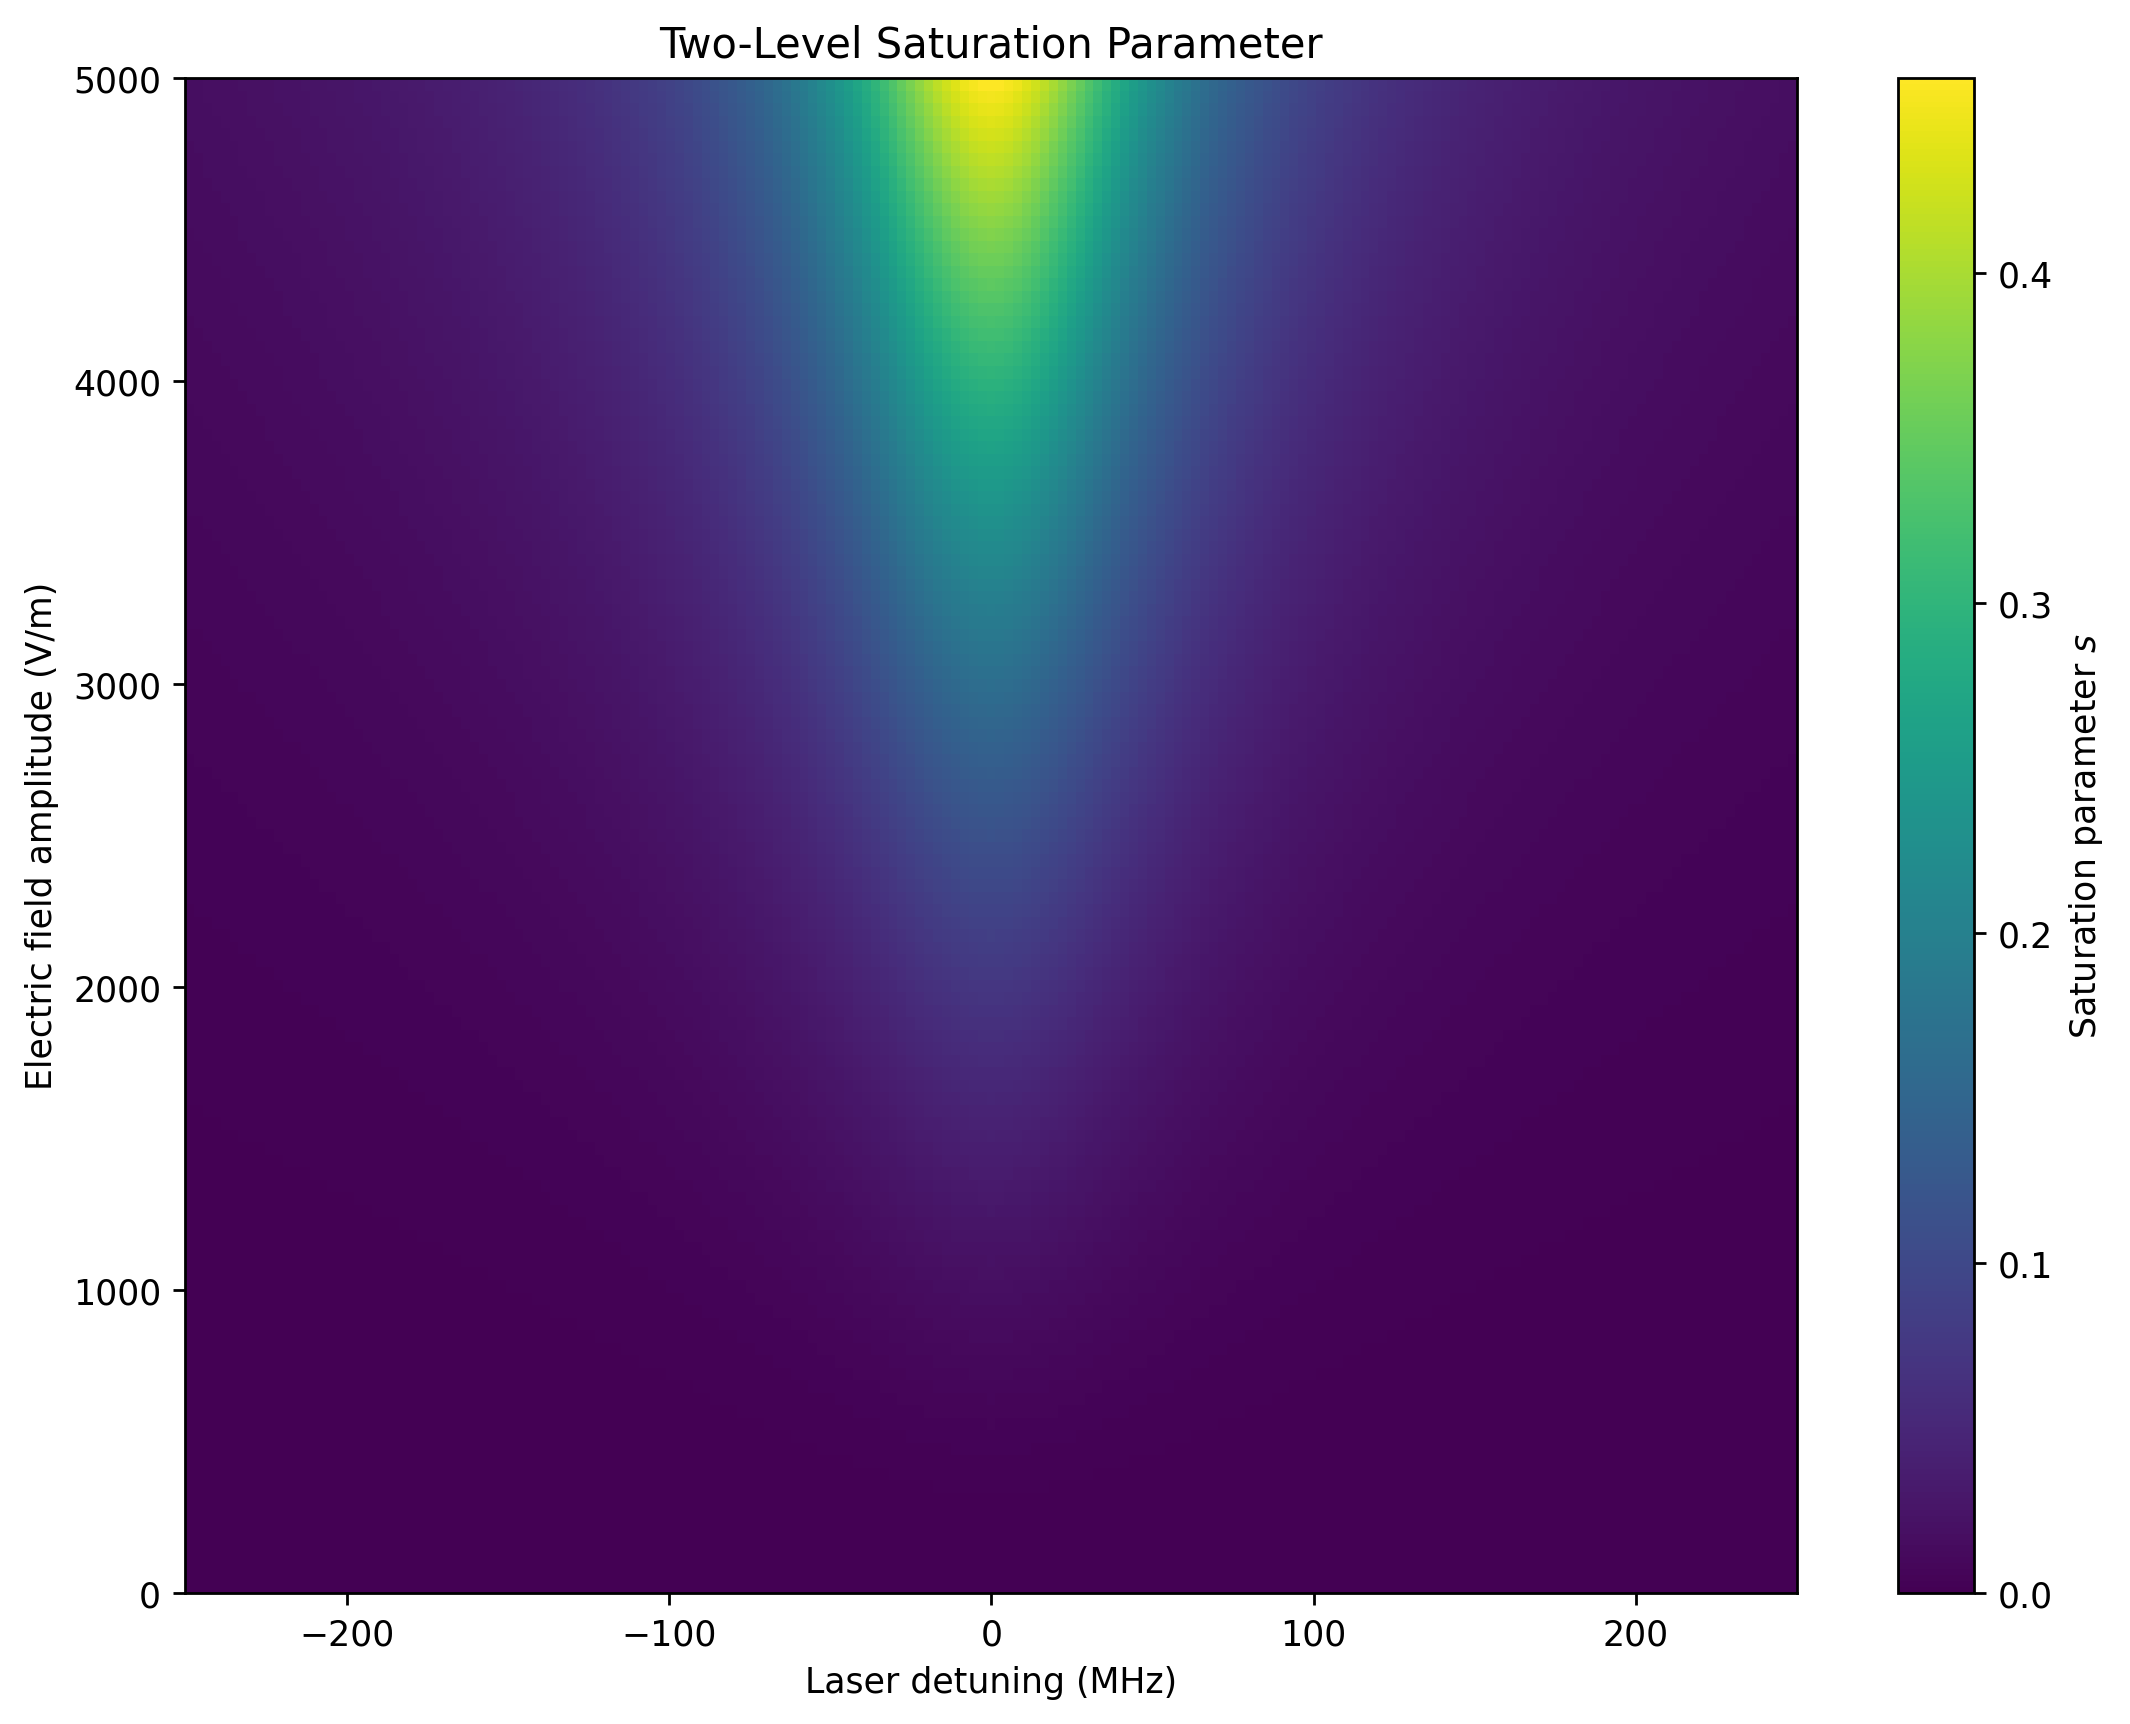

In [11]:
"""Evaluate Fermi Golden Rule transition rates for a driven two-level system.

The default physical case is the hydrogen 1s <-> 2p electric-dipole
transition. QuTiP supplies the quantum-state and operator representation,
and Matplotlib visualizes the transition-rate landscape.
"""

import math
from typing import Final

import matplotlib.pyplot as plt
import numpy as np
import qutip as qt


# ------------------------------------------------------------
# CONTROL KNOBS
# ------------------------------------------------------------
PLOT_DPI = 250

# Hydrogen 1s <-> 2p transition.
TRANSITION_ENERGY_EV = 10.20427
DIPOLE_POSITION_A0 = 2.0**8 / (3.0**5 * math.sqrt(2.0))
EXCITED_STATE_LIFETIME_S = 1.60e-9

# Additional pure dephasing. Zero gives the lifetime-limited case.
PURE_DEPHASING_MHZ = 0.0

# Drive-field sweep.
FIELD_MIN_V_M = 0.0
FIELD_MAX_V_M = 5_000.0
NUM_FIELD_POINTS = 121

# Frequency sweep about resonance.
DETUNING_MIN_MHZ = -250.0
DETUNING_MAX_MHZ = 250.0
NUM_DETUNING_POINTS = 181

# QuTiP comparison points.
SPOT_CHECK_FIELDS_V_M = (100.0, 1_000.0, 5_000.0)
SPOT_CHECK_DETUNINGS_MHZ = (-100.0, 0.0, 100.0)

# Figure dimensions.
SURFACE_FIGURE_SIZE = (10.0, 7.5)
HEATMAP_FIGURE_SIZE = (9.0, 7.0)

plt.rcParams["figure.dpi"] = PLOT_DPI


# ------------------------------------------------------------
# PHYSICAL CONSTANTS
# ------------------------------------------------------------
HBAR_J_S: Final = 1.054_571_817e-34
ELEMENTARY_CHARGE_C: Final = 1.602_176_634e-19
BOHR_RADIUS_M: Final = 5.291_772_109_03e-11
SPEED_OF_LIGHT_M_S: Final = 299_792_458.0
ELECTRON_VOLT_J: Final = 1.602_176_634e-19


# ------------------------------------------------------------
# DERIVED TRANSITION PARAMETERS
# ------------------------------------------------------------
TRANSITION_ENERGY_J = TRANSITION_ENERGY_EV * ELECTRON_VOLT_J
OMEGA_0_RAD_S = TRANSITION_ENERGY_J / HBAR_J_S
FREQUENCY_0_HZ = OMEGA_0_RAD_S / (2.0 * math.pi)
WAVELENGTH_0_M = SPEED_OF_LIGHT_M_S / FREQUENCY_0_HZ

DIPOLE_POSITION_M = DIPOLE_POSITION_A0 * BOHR_RADIUS_M
DIPOLE_C_M = ELEMENTARY_CHARGE_C * DIPOLE_POSITION_M

GAMMA_1_RAD_S = 1.0 / EXCITED_STATE_LIFETIME_S
GAMMA_PHI_RAD_S = (
    2.0
    * math.pi
    * PURE_DEPHASING_MHZ
    * 1.0e6
)
GAMMA_2_RAD_S = (
    0.5 * GAMMA_1_RAD_S
    + GAMMA_PHI_RAD_S
)


# ------------------------------------------------------------
# QUTIP TWO-LEVEL REPRESENTATION
# ------------------------------------------------------------
GROUND_STATE = qt.basis(2, 0)
EXCITED_STATE = qt.basis(2, 1)

EXCITED_PROJECTOR = EXCITED_STATE * EXCITED_STATE.dag()

LOWERING_OPERATOR = qt.destroy(2)
SIGMA_X = qt.sigmax()
SIGMA_Z = qt.sigmaz()

DIPOLE_OPERATOR = DIPOLE_C_M * (
    EXCITED_STATE * GROUND_STATE.dag()
    + GROUND_STATE * EXCITED_STATE.dag()
)

DIPOLE_MATRIX_ELEMENT = DIPOLE_OPERATOR.matrix_element(
    EXCITED_STATE.dag(),
    GROUND_STATE,
)


# ------------------------------------------------------------
# FERMI GOLDEN RULE FUNCTIONS
# ------------------------------------------------------------
def lorentzian_delta_energy(
    energy_mismatch_j: np.ndarray | float,
    gamma_energy_j: float,
) -> np.ndarray | float:
    """Approximate the Dirac delta with a normalized Lorentzian.

    Args:
        energy_mismatch_j: Energy mismatch in joules.
        gamma_energy_j: Lorentzian half width at half maximum in joules.

    Returns:
        Broadened delta function in inverse joules.
    """
    numerator = gamma_energy_j / math.pi
    denominator = energy_mismatch_j**2 + gamma_energy_j**2

    return numerator / denominator


def fermi_golden_rule_rate(
    field_v_m: np.ndarray | float,
    detuning_rad_s: np.ndarray | float,
) -> np.ndarray | float:
    """Calculate the Lorentzian-broadened Fermi Golden Rule rate.

    Args:
        field_v_m: Peak electric field amplitude in volts per meter.
        detuning_rad_s: Drive detuning from resonance in radians per second.

    Returns:
        Transition rate in inverse seconds.
    """
    interaction_matrix_element_j = (
        0.5
        * abs(DIPOLE_MATRIX_ELEMENT)
        * field_v_m
    )

    energy_mismatch_j = (
        HBAR_J_S
        * detuning_rad_s
    )

    gamma_energy_j = (
        HBAR_J_S
        * GAMMA_2_RAD_S
    )

    broadened_delta = lorentzian_delta_energy(
        energy_mismatch_j,
        gamma_energy_j,
    )

    return (
        2.0
        * math.pi
        / HBAR_J_S
        * interaction_matrix_element_j**2
        * broadened_delta
    )


def rabi_frequency(
    field_v_m: np.ndarray | float,
) -> np.ndarray | float:
    """Calculate the resonant Rabi angular frequency.

    Args:
        field_v_m: Peak electric field amplitude in volts per meter.

    Returns:
        Rabi angular frequency in radians per second.
    """
    return (
        abs(DIPOLE_MATRIX_ELEMENT)
        * field_v_m
        / HBAR_J_S
    )


def saturation_parameter(
    field_v_m: np.ndarray | float,
    detuning_rad_s: np.ndarray | float,
) -> np.ndarray | float:
    """Calculate the two-level optical saturation parameter.

    Args:
        field_v_m: Peak electric field amplitude in volts per meter.
        detuning_rad_s: Detuning in radians per second.

    Returns:
        Dimensionless saturation parameter.
    """
    omega_rabi = rabi_frequency(field_v_m)

    numerator = (
        omega_rabi**2
        * GAMMA_2_RAD_S
    )

    denominator = (
        GAMMA_1_RAD_S
        * (
            detuning_rad_s**2
            + GAMMA_2_RAD_S**2
        )
    )

    return numerator / denominator


def optical_bloch_scattering_rate(
    field_v_m: np.ndarray | float,
    detuning_rad_s: np.ndarray | float,
) -> np.ndarray | float:
    """Calculate the saturated two-level steady-state scattering rate.

    This expression approaches the Fermi Golden Rule result in the
    weak-drive limit.

    Args:
        field_v_m: Peak electric field amplitude in volts per meter.
        detuning_rad_s: Detuning in radians per second.

    Returns:
        Steady-state photon scattering rate in inverse seconds.
    """
    golden_rate = fermi_golden_rule_rate(
        field_v_m,
        detuning_rad_s,
    )

    saturation = saturation_parameter(
        field_v_m,
        detuning_rad_s,
    )

    return golden_rate / (1.0 + saturation)


# ------------------------------------------------------------
# QUTIP STEADY-STATE CHECK
# ------------------------------------------------------------
def qutip_steady_state_scattering_rate(
    field_v_m: float,
    detuning_rad_s: float,
) -> float:
    """Calculate the steady-state scattering rate with QuTiP.

    QuTiP Hamiltonian entries use angular-frequency units here, which
    corresponds to setting hbar equal to one inside the solver.

    Args:
        field_v_m: Peak electric field amplitude in volts per meter.
        detuning_rad_s: Detuning in radians per second.

    Returns:
        Steady-state spontaneous-emission flux in inverse seconds.
    """
    omega_rabi = float(
        rabi_frequency(field_v_m)
    )

    rotating_frame_hamiltonian = (
        -0.5 * detuning_rad_s * SIGMA_Z
        + 0.5 * omega_rabi * SIGMA_X
    )

    collapse_operators = [
        math.sqrt(GAMMA_1_RAD_S)
        * LOWERING_OPERATOR
    ]

    if GAMMA_PHI_RAD_S > 0.0:
        collapse_operators.append(
            math.sqrt(
                GAMMA_PHI_RAD_S / 2.0
            )
            * SIGMA_Z
        )

    steady_state = qt.steadystate(
        rotating_frame_hamiltonian,
        collapse_operators,
    )

    excited_population = float(
        np.real(
            qt.expect(
                EXCITED_PROJECTOR,
                steady_state,
            )
        )
    )

    return (
        GAMMA_1_RAD_S
        * excited_population
    )


# ------------------------------------------------------------
# PARAMETER GRID
# ------------------------------------------------------------
field_axis_v_m = np.linspace(
    FIELD_MIN_V_M,
    FIELD_MAX_V_M,
    NUM_FIELD_POINTS,
)

detuning_axis_mhz = np.linspace(
    DETUNING_MIN_MHZ,
    DETUNING_MAX_MHZ,
    NUM_DETUNING_POINTS,
)

detuning_grid_mhz, field_grid_v_m = np.meshgrid(
    detuning_axis_mhz,
    field_axis_v_m,
)

detuning_grid_rad_s = (
    2.0
    * math.pi
    * detuning_grid_mhz
    * 1.0e6
)

fgr_rate_s = fermi_golden_rule_rate(
    field_grid_v_m,
    detuning_grid_rad_s,
)

bloch_rate_s = optical_bloch_scattering_rate(
    field_grid_v_m,
    detuning_grid_rad_s,
)

saturation_grid = saturation_parameter(
    field_grid_v_m,
    detuning_grid_rad_s,
)

agreement_ratio = np.divide(
    bloch_rate_s,
    fgr_rate_s,
    out=np.ones_like(bloch_rate_s),
    where=fgr_rate_s > 0.0,
)


# ------------------------------------------------------------
# NUMERICAL SUMMARY
# ------------------------------------------------------------
print("Hydrogen 1s <-> 2p Fermi Golden Rule model")
print("-" * 62)
print(f"QuTiP version: {qt.__version__}")
print(
    "Transition energy: "
    f"{TRANSITION_ENERGY_EV:.6f} eV"
)
print(
    "Central wavelength: "
    f"{WAVELENGTH_0_M * 1.0e9:.4f} nm"
)
print(
    "Dipole position matrix element: "
    f"{DIPOLE_POSITION_A0:.9f} a0"
)
print(
    "Transition dipole magnitude: "
    f"{abs(DIPOLE_MATRIX_ELEMENT):.6e} C m"
)
print(
    "Population decay rate gamma_1: "
    f"{GAMMA_1_RAD_S:.6e} s^-1"
)
print(
    "Coherence HWHM gamma_2 / 2pi: "
    f"{GAMMA_2_RAD_S / (2.0 * math.pi) / 1.0e6:.4f} MHz"
)


# ------------------------------------------------------------
# QUTIP SPOT CHECKS
# ------------------------------------------------------------
print()
print("QuTiP steady-state comparison")
print("-" * 88)
print(
    f"{'Field (V/m)':>12}"
    f"{'Detuning (MHz)':>17}"
    f"{'FGR (s^-1)':>18}"
    f"{'Bloch (s^-1)':>18}"
    f"{'QuTiP (s^-1)':>18}"
)

for field_value in SPOT_CHECK_FIELDS_V_M:
    for detuning_mhz in SPOT_CHECK_DETUNINGS_MHZ:
        detuning_rad_s = (
            2.0
            * math.pi
            * detuning_mhz
            * 1.0e6
        )

        golden_rate = float(
            fermi_golden_rule_rate(
                field_value,
                detuning_rad_s,
            )
        )

        analytic_rate = float(
            optical_bloch_scattering_rate(
                field_value,
                detuning_rad_s,
            )
        )

        qutip_rate = (
            qutip_steady_state_scattering_rate(
                field_value,
                detuning_rad_s,
            )
        )

        print(
            f"{field_value:12.1f}"
            f"{detuning_mhz:17.1f}"
            f"{golden_rate:18.6e}"
            f"{analytic_rate:18.6e}"
            f"{qutip_rate:18.6e}"
        )


# ------------------------------------------------------------
# SURFACE PLOT
# ------------------------------------------------------------
figure = plt.figure(
    figsize=SURFACE_FIGURE_SIZE
)

axis = figure.add_subplot(
    111,
    projection="3d",
)

axis.plot_surface(
    detuning_grid_mhz,
    field_grid_v_m,
    fgr_rate_s / 1.0e6,
    linewidth=0.0,
    antialiased=True,
)

axis.set_xlabel("Laser detuning (MHz)")
axis.set_ylabel("Electric field amplitude (V/m)")
axis.set_zlabel(
    r"FGR transition rate ($10^6$ s$^{-1}$)"
)
axis.set_title(
    "Fermi Golden Rule Surface for "
    r"Hydrogen $1s\leftrightarrow2p$"
)

axis.view_init(
    elev=30.0,
    azim=-130.0,
)

figure.tight_layout()
plt.show()


# ------------------------------------------------------------
# FGR RATE HEAT MAP
# ------------------------------------------------------------
figure, axis = plt.subplots(
    figsize=HEATMAP_FIGURE_SIZE
)

image = axis.imshow(
    fgr_rate_s / 1.0e6,
    origin="lower",
    aspect="auto",
    extent=[
        DETUNING_MIN_MHZ,
        DETUNING_MAX_MHZ,
        FIELD_MIN_V_M,
        FIELD_MAX_V_M,
    ],
)

axis.set_xlabel("Laser detuning (MHz)")
axis.set_ylabel("Electric field amplitude (V/m)")
axis.set_title(
    "Fermi Golden Rule Transition Rate"
)

figure.colorbar(
    image,
    ax=axis,
    label=r"Transition rate ($10^6$ s$^{-1}$)",
)

figure.tight_layout()
plt.show()


# ------------------------------------------------------------
# FGR VALIDITY HEAT MAP
# ------------------------------------------------------------
figure, axis = plt.subplots(
    figsize=HEATMAP_FIGURE_SIZE
)

image = axis.imshow(
    agreement_ratio,
    origin="lower",
    aspect="auto",
    extent=[
        DETUNING_MIN_MHZ,
        DETUNING_MAX_MHZ,
        FIELD_MIN_V_M,
        FIELD_MAX_V_M,
    ],
    vmin=0.0,
    vmax=1.0,
)

axis.set_xlabel("Laser detuning (MHz)")
axis.set_ylabel("Electric field amplitude (V/m)")
axis.set_title(
    "Weak-Drive FGR Agreement with "
    "Saturated Two-Level Dynamics"
)

figure.colorbar(
    image,
    ax=axis,
    label="Bloch rate / FGR rate",
)

figure.tight_layout()
plt.show()


# ------------------------------------------------------------
# SATURATION HEAT MAP
# ------------------------------------------------------------
figure, axis = plt.subplots(
    figsize=HEATMAP_FIGURE_SIZE
)

image = axis.imshow(
    saturation_grid,
    origin="lower",
    aspect="auto",
    extent=[
        DETUNING_MIN_MHZ,
        DETUNING_MAX_MHZ,
        FIELD_MIN_V_M,
        FIELD_MAX_V_M,
    ],
)

axis.set_xlabel("Laser detuning (MHz)")
axis.set_ylabel("Electric field amplitude (V/m)")
axis.set_title(
    "Two-Level Saturation Parameter"
)

figure.colorbar(
    image,
    ax=axis,
    label=r"Saturation parameter $s$",
)

figure.tight_layout()
plt.show()